# 08 — Component Modelling

## Main question

**Among incidents with reported aircraft damage, which aircraft-component damage outcomes have enough statistical support and predictive reliability to be retained for downstream consequence simulation?**

This notebook is a **secondary, decision-gated modelling stage**. It does not assume that every FAA component checkbox deserves a predictive model. Instead, it:

1. audits every original `DAM_*` field;
2. verifies that component outcomes are multilabel;
3. defines defensible component groups without overwriting the original FAA fields;
4. excludes leakage and other post-event information from predictors;
5. screens targets for adequate chronological support before expensive tuning;
6. tunes Logistic Regression, Random Forest, and XGBoost with `RandomizedSearchCV` using expanding chronological folds;
7. evaluates discrimination, classification behaviour, and probability quality;
8. performs forward calibration and threshold exploration;
9. unlocks 2022–2024 only after target/model/calibration decisions are fixed; and
10. classifies every component as **MODELLED**, **DESCRIPTIVE ONLY**, or **EXCLUDED** for downstream simulation.

The component stage is conditional on a reported strike **and** observed aircraft damage:

$$
P(\text{component damage}=1 \mid \text{INDICATED\_DAMAGE}=1,\ \text{scenario inputs})
$$

It does **not** predict the occurrence of a wildlife strike and it does **not** use observed severity as an input.


# 1. Methodological decisions and academic justification

## 1.1 Why this is a multilabel problem

The FAA records separate binary `DAM_*` indicators for aircraft parts such as the radome, windshield, engines, wing/rotor, fuselage, landing gear, and tail. More than one indicator can be positive for the same damaged strike, so the targets are not mutually exclusive classes. This is therefore a **multilabel outcome structure**.

The primary implementation uses **binary relevance**: one binary probability model is fitted per retained component target. This is transparent, easy to validate separately, and consistent with the capstone's simulation design. Its limitation is that independently fitted models do not explicitly learn dependence among labels. Component co-occurrence is therefore audited and saved for Notebook 10, where this limitation must be acknowledged if component outcomes are sampled independently.

## 1.2 Audit original fields first; group only where substantively defensible

The existing Notebook 08 grouped components before showing whether the original FAA outcomes had adequate support. This notebook reverses that order.

All original component fields are audited first. Broader targets are then created only where they represent a coherent aircraft area/system and improve support without hiding the original variables:

- `ENGINE_DAMAGE`: any of `DAM_ENG1`–`DAM_ENG4`;
- `FORWARD_COCKPIT_DAMAGE`: any of `DAM_RAD`, `DAM_WINDSHLD`, `DAM_NOSE`;
- `WING_ROTOR_DAMAGE`: `DAM_WING_ROT`;
- `PROPELLER_DAMAGE`: `DAM_PROP`;
- `FUSELAGE_DAMAGE`: `DAM_FUSE`;
- `LANDING_GEAR_DAMAGE`: `DAM_LG`;
- `TAIL_DAMAGE`: `DAM_TAIL`;
- `LIGHTS_DAMAGE`: `DAM_LGHTS`.

`DAM_OTHER` is retained for descriptive analysis but is **not a simulation target** because “other” is semantically heterogeneous and does not identify a stable aircraft component.

Sparse engine-position fields (`DAM_ENG3`, `DAM_ENG4`) are not fitted as separate targets; their positives remain represented inside the broader `ENGINE_DAMAGE` outcome.

## 1.3 Severity-model decisions from Notebook 07 that carry forward

Notebook 07 matters here as a **methodological precedent**:

- the same locked chronological periods are retained;
- the same five expanding pre-2019 folds are used for tuning;
- binary outcomes are ranked primarily with PR-AUC / average precision;
- precision, recall, F1, confusion matrices, threshold behaviour, Brier score, and log loss are also reported;
- calibration is tested forward in time;
- the final test remains locked until modelling decisions are frozen;
- secondary models must pass an explicit decision gate before entering simulation.

Notebook 07's retained **known-severity binary model is not used as a predictor here**. Doing so would make component predictions depend on another estimated downstream outcome, propagate severity-model error, and complicate scenario availability. Component probabilities are therefore estimated directly from scenario-eligible strike, wildlife, aircraft, flight, time, and geography features.

## 1.4 Hyperparameter tuning with RandomizedSearchCV

`RandomizedSearchCV` is used instead of exhaustive grid search for the viable targets. Random search is appropriate when several hyperparameters are available and the full Cartesian grid would create many low-value fits. The randomization affects **which hyperparameter settings are sampled**; it does not randomize temporal validation. The `cv` argument receives explicit expanding chronological train/validation indices.

The search budget is intentionally bounded and reproducible:

- Logistic Regression: 10 sampled settings per target/feature set;
- Random Forest: 16 sampled settings per target/feature set;
- XGBoost: 20 sampled settings per target/feature set;
- five expanding chronological folds;
- two approved feature sets (`extended_geographic`, `airport_aware`).

## 1.5 Feasibility gate is an operational rule, not a universal statistical law

There is no universal positive-count cutoff that proves a binary outcome is modelable. This notebook therefore uses a **conservative project-level screening rule** to avoid fitting targets whose metrics would be dominated by very few positive observations:

- at least 200 positives in 1990–2018 training;
- at least 30 positives in the 2019–2021 development/validation period; and
- at least 20 positives in every pre-2019 chronological validation fold.

These numbers are not presented as published universal thresholds. They are transparent engineering safeguards for this dataset and evaluation design. Passing this support gate only permits modelling; it does **not** guarantee that the final model will pass the simulation decision gate.

## 1.6 Why PR-AUC is primary

Several component outcomes are uncommon. Precision-recall evaluation is more informative than accuracy alone for imbalanced binary outcomes because it directly reflects positive-class retrieval and false alarms. The no-skill reference for average precision is closely related to outcome prevalence, so PR-AUC must be interpreted relative to each target's positive rate rather than against a universal value such as 0.30.

## 1.7 Probability quality matters for simulation

Notebook 10 needs probabilities, not only hard class labels. For that reason this notebook evaluates Brier score, log loss, calibration curves, and forward sigmoid/isotonic calibration. Calibration is retained only when it improves forward probability quality; a raw model can remain preferable when calibration worsens it.


# 2. Environment and reproducibility

`xgboost` is retained to match the candidate-model family used in Notebooks 05 and 07. If it is not installed in the active environment, install it once and rerun the import cell.


In [1]:
# Uncomment only if xgboost is missing.
# %pip install -q xgboost


In [2]:
from pathlib import Path
import json
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from scipy.stats import loguniform, randint, uniform

from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

from xgboost import XGBClassifier

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

SEED = 42
np.random.seed(SEED)


# 3. Portable project paths

The notebook searches upward for the repository root. The canonical analytical input should ultimately be:

`data/processed/faa_strikes_analytical.csv`

Persistent artifacts follow the same project convention as Notebook 07:

- `outputs/08_component_modelling/` — audits, metrics, predictions, decisions;
- `models/candidates/08_component_modelling/` — optional candidate models;
- `models/final/08_component_modelling/` — only component models that pass the decision gate.


In [ ]:
ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "data").exists() or (candidate / "models").exists():
        ROOT = candidate
        break

DATA_CANDIDATES = [
    ROOT / "data" / "processed" / "faa_strikes_analytical.csv",
    ROOT / "data" / "processed" / "faa_strikes_analytical(4).csv",
    Path("/mnt/data/faa_strikes_analytical(4).csv"),
]
DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not locate faa_strikes_analytical.csv. "
        "Update DATA_CANDIDATES to point to the canonical Notebook 02 output."
    )

FEATURE_LIST_CANDIDATES = [
    ROOT / "outputs" / "feature_lists.json",
    ROOT / "data" / "processed" / "feature_lists.json",
    ROOT / "docs" / "feature_lists.json",
]
FEATURE_LIST_PATH = next((p for p in FEATURE_LIST_CANDIDATES if p.exists()), None)

OUTPUT_DIR = ROOT / "outputs" / "08_component_modelling"
CANDIDATE_MODEL_DIR = ROOT / "models" / "candidates" / "08_component_modelling"
FINAL_MODEL_DIR = ROOT / "models" / "final" / "08_component_modelling"

for folder in [OUTPUT_DIR, CANDIDATE_MODEL_DIR, FINAL_MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("DATA_PATH:", DATA_PATH)
print("FEATURE_LIST_PATH:", FEATURE_LIST_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("CANDIDATE_MODEL_DIR:", CANDIDATE_MODEL_DIR)
print("FINAL_MODEL_DIR:", FINAL_MODEL_DIR)


ROOT: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis
DATA_PATH: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis\data\processed\faa_strikes_analytical.csv
FEATURE_LIST_PATH: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis\docs\feature_lists.json
OUTPUT_DIR: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis\outputs\08_component_modelling
CANDIDATE_MODEL_DIR: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis\models\candidates\08_component_modelling
FINAL_MODEL_DIR: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis\models\final\08_component_modelling


# 4. Load the canonical analytical dataset

Notebook 08 consumes Notebook 02's analytical dataset rather than redefining cleaning rules. Component checkboxes are legitimate **targets here**, but they remain forbidden predictors.


In [4]:
df = pd.read_csv(DATA_PATH, low_memory=False)

RAW_COMPONENTS = [
    "DAM_RAD", "DAM_WINDSHLD", "DAM_NOSE",
    "DAM_ENG1", "DAM_ENG2", "DAM_ENG3", "DAM_ENG4",
    "DAM_PROP", "DAM_WING_ROT", "DAM_FUSE", "DAM_LG",
    "DAM_TAIL", "DAM_LGHTS", "DAM_OTHER",
]

required = {"INDEX_NR", "INCIDENT_YEAR", "INDICATED_DAMAGE", *RAW_COMPONENTS}
missing = sorted(required - set(df.columns))
if missing:
    raise KeyError(f"Required columns missing from analytical dataset: {missing}")

print("Analytical rows:", len(df))
print("Columns:", df.shape[1])
print("Year range:", int(df["INCIDENT_YEAR"].min()), "to", int(df["INCIDENT_YEAR"].max()))


Analytical rows: 319107
Columns: 150
Year range: 1990 to 2024


# 5. Restrict to the correct component-modelling population

Component damage is only meaningful for this stage when `INDICATED_DAMAGE == 1`. The undamaged population is not used as a negative class for component models because doing so would mostly teach the model the already-solved Notebook 05 damage decision.


In [5]:
damaged = df.loc[df["INDICATED_DAMAGE"].eq(1)].copy()

population_audit = pd.DataFrame({
    "measure": [
        "All analytical incidents",
        "Damaged incidents",
        "Damaged share",
    ],
    "value": [
        len(df),
        len(damaged),
        damaged.shape[0] / df.shape[0],
    ],
})
display(population_audit)
population_audit.to_csv(OUTPUT_DIR / "component_population_audit.csv", index=False)


,measure,value
0,All analytical incidents,319107.00000
1,Damaged incidents,20908.00000
2,Damaged share,0.06552


### Interpetartion — component population

The component-modelling population contains 20,908 incidents with reported aircraft damage, representing approximately 6.6% of the 319,107 analytical incidents. Notebook 08 is therefore conditional on `INDICATED_DAMAGE = 1`. Undamaged incidents are deliberately excluded because the purpose of this stage is not to estimate whether damage occurs, which was already addressed in Notebook 05, but to estimate which aircraft components may be involved once damage has occurred.

# 6. Original FAA component feasibility audit

The checklist requires positive, negative, missing, and positive-rate counts for **every component** before grouping or modelling.


In [6]:
component_audit_rows = []

for component in RAW_COMPONENTS:
    s = damaged[component]
    nonbinary = sorted(set(s.dropna().unique()) - {0, 1, 0.0, 1.0})
    component_audit_rows.append({
        "component": component,
        "positive": int((s == 1).sum()),
        "negative": int((s == 0).sum()),
        "missing": int(s.isna().sum()),
        "positive_rate": float((s == 1).mean()),
        "nonbinary_values": ", ".join(map(str, nonbinary)),
    })

raw_component_audit = pd.DataFrame(component_audit_rows).sort_values(
    "positive", ascending=False
)
display(raw_component_audit)
raw_component_audit.to_csv(OUTPUT_DIR / "raw_component_feasibility.csv", index=False)

assert raw_component_audit["nonbinary_values"].eq("").all(), (
    "At least one DAM_* field contains unexpected non-binary values. "
    "Review Notebook 02 before continuing."
)


,component,positive,negative,missing,positive_rate,nonbinary_values
8,DAM_WING_ROT,6296,14612,0,0.301129,
3,DAM_ENG1,3085,17823,0,0.147551,
4,DAM_ENG2,2602,18306,0,0.124450,
13,DAM_OTHER,2455,18453,0,0.117419,
0,DAM_RAD,2105,18803,0,0.100679,
2,DAM_NOSE,1763,19145,0,0.084322,
1,DAM_WINDSHLD,1468,19440,0,0.070212,
10,DAM_LG,1308,19600,0,0.062560,
9,DAM_FUSE,1209,19699,0,0.057825,
11,DAM_TAIL,1052,19856,0,0.050316,


### Interpretation — original component support

Component support varies substantially among the damaged incidents. `DAM_WING_ROT` is the most frequently reported component outcome with 6,296 positive cases (30.1%), followed by `DAM_ENG1` with 3,085 (14.8%), `DAM_ENG2` with 2,602 (12.4%), and `DAM_RAD` with 2,105 (10.1%). Windshield, landing gear, fuselage, tail, lights, and propeller damage occur less frequently but still have several hundred observations.

In contrast, `DAM_ENG3` and `DAM_ENG4` contain only 167 and 68 positive cases, respectively, making them poorly supported as standalone modelling targets. Their information is therefore better represented within the broader `ENGINE_DAMAGE` outcome.

Missingness is zero for all audited `DAM_*` fields following the documented Notebook 02 treatment of the FAA checkbox variables. The comparatively low prevalence of some component outcomes should not be interpreted as evidence that those components are operationally unimportant; it primarily indicates reduced statistical support for predictive modelling.


# 7. Verify multilabel structure and component co-occurrence

If multiple `DAM_*` indicators can be positive on the same row, component outcomes cannot be represented as one mutually exclusive multiclass target.


In [7]:
damaged["RAW_COMPONENT_LABEL_COUNT"] = damaged[RAW_COMPONENTS].sum(axis=1)

multilabel_summary = pd.DataFrame({
    "measure": [
        "Damaged incidents",
        "At least one DAM_* positive",
        "No DAM_* positive despite INDICATED_DAMAGE=1",
        "Exactly one component positive",
        "More than one component positive",
        "Maximum positive components on one incident",
        "Mean label cardinality",
    ],
    "value": [
        len(damaged),
        int((damaged["RAW_COMPONENT_LABEL_COUNT"] >= 1).sum()),
        int((damaged["RAW_COMPONENT_LABEL_COUNT"] == 0).sum()),
        int((damaged["RAW_COMPONENT_LABEL_COUNT"] == 1).sum()),
        int((damaged["RAW_COMPONENT_LABEL_COUNT"] > 1).sum()),
        int(damaged["RAW_COMPONENT_LABEL_COUNT"].max()),
        float(damaged["RAW_COMPONENT_LABEL_COUNT"].mean()),
    ],
})
display(multilabel_summary)
multilabel_summary.to_csv(OUTPUT_DIR / "multilabel_summary.csv", index=False)

cooccurrence_counts = damaged[RAW_COMPONENTS].T.dot(damaged[RAW_COMPONENTS]).astype(int)
cooccurrence_counts.to_csv(OUTPUT_DIR / "raw_component_cooccurrence_counts.csv")
display(cooccurrence_counts)


,measure,value
0,Damaged incidents,20908.000000
1,At least one DAM_* positive,20908.000000
2,No DAM_* positive despite INDICATED_DAMAGE=1,0.000000
3,Exactly one component positive,17979.000000
4,More than one component positive,2929.000000
5,Maximum positive components on one incident,11.000000
6,Mean label cardinality,1.210541


,DAM_RAD,DAM_WINDSHLD,DAM_NOSE,DAM_ENG1,DAM_ENG2,DAM_ENG3,DAM_ENG4,DAM_PROP,DAM_WING_ROT,DAM_FUSE,DAM_LG,DAM_TAIL,DAM_LGHTS,DAM_OTHER
DAM_RAD,2105,35,243,86,71,4,1,21,128,99,53,36,30,120
DAM_WINDSHLD,35,1468,110,43,23,0,0,42,133,118,42,73,33,152
DAM_NOSE,243,110,1763,142,69,2,1,111,207,212,126,69,70,166
DAM_ENG1,86,43,142,3085,190,7,1,173,250,128,142,68,72,117
DAM_ENG2,71,23,69,190,2602,3,3,71,155,71,84,40,44,67
DAM_ENG3,4,0,2,7,3,167,5,1,12,7,4,3,3,3
DAM_ENG4,1,0,1,1,3,5,68,1,5,1,1,1,1,0
DAM_PROP,21,42,111,173,71,1,1,701,160,105,182,46,34,74
DAM_WING_ROT,128,133,207,250,155,12,5,160,6296,256,282,170,179,239
DAM_FUSE,99,118,212,128,71,7,1,105,256,1209,146,111,65,148


### Interpretation — multilabel structure

All 20,908 damaged incidents contain at least one positive FAA component indicator. Most incidents, 17,979, contain exactly one reported damaged component, while 2,929 incidents contain damage to more than one component. The maximum observed component count for a single incident is 11, and mean label cardinality is approximately 1.21.

These results confirm that component damage is a multilabel problem. An incident may simultaneously involve an engine, wing, landing gear, or other aircraft components, so a single multiclass target would incorrectly force mutually exclusive outcomes. Separate binary component models are therefore more appropriate. The co-occurrence results must nevertheless be remembered in Notebook 10 because independently sampling component probabilities does not automatically reproduce observed dependencies between components.


# 8. Define modelling targets without changing the FAA source fields

These engineered outcomes are created only inside Notebook 08. Original `DAM_*` fields remain unchanged and are saved in the audit outputs.


In [8]:
COMPONENT_GROUPS = {
    "ENGINE_DAMAGE": ["DAM_ENG1", "DAM_ENG2", "DAM_ENG3", "DAM_ENG4"],
    "FORWARD_COCKPIT_DAMAGE": ["DAM_RAD", "DAM_WINDSHLD", "DAM_NOSE"],
    "WING_ROTOR_DAMAGE": ["DAM_WING_ROT"],
    "PROPELLER_DAMAGE": ["DAM_PROP"],
    "FUSELAGE_DAMAGE": ["DAM_FUSE"],
    "LANDING_GEAR_DAMAGE": ["DAM_LG"],
    "TAIL_DAMAGE": ["DAM_TAIL"],
    "LIGHTS_DAMAGE": ["DAM_LGHTS"],
}

for target, members in COMPONENT_GROUPS.items():
    damaged[target] = damaged[members].max(axis=1).astype(int)

component_mapping = pd.DataFrame([
    {
        "model_target": target,
        "source_fields": ", ".join(members),
        "definition": f"1 if any of: {', '.join(members)}",
    }
    for target, members in COMPONENT_GROUPS.items()
])
display(component_mapping)
component_mapping.to_csv(OUTPUT_DIR / "component_target_mapping.csv", index=False)


,model_target,source_fields,definition
0,ENGINE_DAMAGE,"DAM_ENG1, DAM_ENG2, DAM_ENG3, DAM_ENG4","1 if any of: DAM_ENG1, DAM_ENG2, DAM_ENG3, DAM..."
1,FORWARD_COCKPIT_DAMAGE,"DAM_RAD, DAM_WINDSHLD, DAM_NOSE","1 if any of: DAM_RAD, DAM_WINDSHLD, DAM_NOSE"
2,WING_ROTOR_DAMAGE,DAM_WING_ROT,1 if any of: DAM_WING_ROT
3,PROPELLER_DAMAGE,DAM_PROP,1 if any of: DAM_PROP
4,FUSELAGE_DAMAGE,DAM_FUSE,1 if any of: DAM_FUSE
5,LANDING_GEAR_DAMAGE,DAM_LG,1 if any of: DAM_LG
6,TAIL_DAMAGE,DAM_TAIL,1 if any of: DAM_TAIL
7,LIGHTS_DAMAGE,DAM_LGHTS,1 if any of: DAM_LGHTS


# 9. Classify every original component before predictive modelling

The statuses below record the approved **pre-modelling routing decisions**. `CANDIDATE VIA GROUP` means the original FAA component is represented by a broader target that must still pass validation and the final decision gate. `DAM_OTHER` is descriptive-only from the outset.


In [9]:
ORIGINAL_COMPONENT_DECISIONS = {
    "DAM_RAD": ("CANDIDATE VIA GROUP", "FORWARD_COCKPIT_DAMAGE", "Retained within coherent forward-airframe/cockpit group."),
    "DAM_WINDSHLD": ("CANDIDATE VIA GROUP", "FORWARD_COCKPIT_DAMAGE", "Retained within coherent forward-airframe/cockpit group."),
    "DAM_NOSE": ("CANDIDATE VIA GROUP", "FORWARD_COCKPIT_DAMAGE", "Retained within coherent forward-airframe/cockpit group."),
    "DAM_ENG1": ("CANDIDATE VIA GROUP", "ENGINE_DAMAGE", "Retained within any-engine damage target."),
    "DAM_ENG2": ("CANDIDATE VIA GROUP", "ENGINE_DAMAGE", "Retained within any-engine damage target."),
    "DAM_ENG3": ("CANDIDATE VIA GROUP", "ENGINE_DAMAGE", "Too sparse for standalone modelling; retained within any-engine target."),
    "DAM_ENG4": ("CANDIDATE VIA GROUP", "ENGINE_DAMAGE", "Too sparse for standalone modelling; retained within any-engine target."),
    "DAM_PROP": ("CANDIDATE VIA GROUP", "PROPELLER_DAMAGE", "Distinct component retained as its own binary target subject to support gate."),
    "DAM_WING_ROT": ("CANDIDATE VIA GROUP", "WING_ROTOR_DAMAGE", "FAA field retained as its own grouped target."),
    "DAM_FUSE": ("CANDIDATE VIA GROUP", "FUSELAGE_DAMAGE", "FAA field retained as its own grouped target."),
    "DAM_LG": ("CANDIDATE VIA GROUP", "LANDING_GEAR_DAMAGE", "FAA field retained as its own grouped target."),
    "DAM_TAIL": ("CANDIDATE VIA GROUP", "TAIL_DAMAGE", "FAA field retained as its own grouped target."),
    "DAM_LGHTS": ("CANDIDATE VIA GROUP", "LIGHTS_DAMAGE", "FAA field retained as its own grouped target subject to support gate."),
    "DAM_OTHER": ("DESCRIPTIVE ONLY", None, "Heterogeneous 'other' category has no stable component meaning for simulation."),
}

original_decision_table = pd.DataFrame([
    {
        "component": component,
        "status": status,
        "model_target": target,
        "rationale": rationale,
    }
    for component, (status, target, rationale) in ORIGINAL_COMPONENT_DECISIONS.items()
])
display(original_decision_table)
original_decision_table.to_csv(OUTPUT_DIR / "original_component_decisions.csv", index=False)


,component,status,model_target,rationale
0,DAM_RAD,CANDIDATE VIA GROUP,FORWARD_COCKPIT_DAMAGE,Retained within coherent forward-airframe/cock...
1,DAM_WINDSHLD,CANDIDATE VIA GROUP,FORWARD_COCKPIT_DAMAGE,Retained within coherent forward-airframe/cock...
2,DAM_NOSE,CANDIDATE VIA GROUP,FORWARD_COCKPIT_DAMAGE,Retained within coherent forward-airframe/cock...
3,DAM_ENG1,CANDIDATE VIA GROUP,ENGINE_DAMAGE,Retained within any-engine damage target.
4,DAM_ENG2,CANDIDATE VIA GROUP,ENGINE_DAMAGE,Retained within any-engine damage target.
5,DAM_ENG3,CANDIDATE VIA GROUP,ENGINE_DAMAGE,Too sparse for standalone modelling; retained ...
6,DAM_ENG4,CANDIDATE VIA GROUP,ENGINE_DAMAGE,Too sparse for standalone modelling; retained ...
7,DAM_PROP,CANDIDATE VIA GROUP,PROPELLER_DAMAGE,Distinct component retained as its own binary ...
8,DAM_WING_ROT,CANDIDATE VIA GROUP,WING_ROTOR_DAMAGE,FAA field retained as its own grouped target.
9,DAM_FUSE,CANDIDATE VIA GROUP,FUSELAGE_DAMAGE,FAA field retained as its own grouped target.


# 10. Locked chronological partitions

The same periods used in Notebooks 05–07 are retained:

- **Training / hyperparameter tuning:** 1990–2018
- **Development validation / model selection and calibration:** 2019–2021
- **Locked final test:** 2022–2024

The final-test period must not influence hyperparameter, target, calibration, or threshold choices.


In [10]:
train_mask = damaged["INCIDENT_YEAR"].between(1990, 2018)
validation_mask = damaged["INCIDENT_YEAR"].between(2019, 2021)
test_mask = damaged["INCIDENT_YEAR"].between(2022, 2024)

split_summary = []
for split_name, mask in [
    ("train_1990_2018", train_mask),
    ("validation_2019_2021", validation_mask),
    ("test_2022_2024_LOCKED", test_mask),
]:
    row = {"split": split_name, "rows": int(mask.sum())}
    # Test label counts are saved for final reporting, not used in feasibility decisions below.
    for target in COMPONENT_GROUPS:
        row[f"{target}_positive"] = int(damaged.loc[mask, target].sum())
        row[f"{target}_rate"] = float(damaged.loc[mask, target].mean())
    split_summary.append(row)

component_split_summary = pd.DataFrame(split_summary)
display(component_split_summary)
component_split_summary.to_csv(OUTPUT_DIR / "component_split_summary.csv", index=False)


,split,rows,ENGINE_DAMAGE_positive,ENGINE_DAMAGE_rate,FORWARD_COCKPIT_DAMAGE_positive,FORWARD_COCKPIT_DAMAGE_rate,WING_ROTOR_DAMAGE_positive,WING_ROTOR_DAMAGE_rate,PROPELLER_DAMAGE_positive,PROPELLER_DAMAGE_rate,FUSELAGE_DAMAGE_positive,FUSELAGE_DAMAGE_rate,LANDING_GEAR_DAMAGE_positive,LANDING_GEAR_DAMAGE_rate,TAIL_DAMAGE_positive,TAIL_DAMAGE_rate,LIGHTS_DAMAGE_positive,LIGHTS_DAMAGE_rate
0,train_1990_2018,16737,4936,0.294915,3971,0.237259,4842,0.289299,609,0.036386,976,0.058314,1116,0.066679,850,0.050786,850,0.050786
1,validation_2019_2021,1925,322,0.167273,463,0.240519,702,0.364675,40,0.020779,113,0.058701,102,0.052987,90,0.046753,72,0.037403
2,test_2022_2024_LOCKED,2246,459,0.204363,536,0.238646,752,0.334817,52,0.023152,120,0.053428,90,0.040071,112,0.049866,109,0.048531


### Interpretation — chronological target support

Component prevalence is not completely stable across time. Engine damage shows the largest shift, decreasing from approximately 29.5% during 1990–2018 to 16.7% in 2019–2021, before increasing to 20.4% in 2022–2024. Wing/rotor damage moves in the opposite direction, increasing from 28.9% during training to 36.5% during validation and remaining elevated at 33.5% in the final test.

Forward cockpit damage is comparatively stable at approximately 24% across all three periods. Landing gear, fuselage, tail, lights, and propeller outcomes remain relatively uncommon, although their prevalence also changes moderately between periods.

These temporal differences support the use of chronological validation rather than random splitting and reinforce the importance of probability calibration. In particular, the substantial engine prevalence shift means that a model may preserve useful ranking ability while requiring calibration to produce reliable later-year probabilities.

# 11. Canonical feature lists and leakage protection

Only scenario-eligible predictors are allowed. The following are forbidden:

- all `DAM_*`, `STR_*`, and `ING_*` fields;
- `DAMAGE_LEVEL` and severity-derived variables;
- injuries, fatalities, costs, aircraft-on-ground time, and effects;
- `INDICATED_DAMAGE` itself (the population is already conditioned on damage);
- reporting/administrative identifiers and the split variable.

Strike-location checkboxes (`STR_*`), ingestion fields (`ING_*`), and inspection/post-event information can be strongly associated with a damaged component, but they are unavailable or contaminated by knowledge of the realized event and therefore would create leakage for scenario prediction.


In [11]:
fallback_feature_lists = {
    "core_features": [
        "SEASON", "MONTH_SIN", "MONTH_COS", "WILDLIFE_TYPE", "SIZE",
        "NUM_STRUCK", "AC_CLASS", "AC_MASS_GROUP", "TYPE_ENG",
        "NUM_ENGS", "WARNED"
    ],
    "extended_features": [
        "SEASON", "MONTH_SIN", "MONTH_COS", "WILDLIFE_TYPE", "SIZE",
        "NUM_STRUCK", "AC_CLASS", "AC_MASS_GROUP", "TYPE_ENG",
        "NUM_ENGS", "WARNED", "PHASE_OF_FLIGHT", "HEIGHT", "SPEED",
        "TIME_OF_DAY", "SKY", "PRECIPITATION", "STATE", "FAAREGION"
    ],
    "airport_aware_features": [
        "SEASON", "MONTH_SIN", "MONTH_COS", "WILDLIFE_TYPE", "SIZE",
        "NUM_STRUCK", "AC_CLASS", "AC_MASS_GROUP", "TYPE_ENG",
        "NUM_ENGS", "WARNED", "PHASE_OF_FLIGHT", "HEIGHT", "SPEED",
        "TIME_OF_DAY", "SKY", "PRECIPITATION", "STATE", "FAAREGION",
        "AIRPORT_ID"
    ],
    "seed": SEED,
}

if FEATURE_LIST_PATH is not None:
    with open(FEATURE_LIST_PATH, "r", encoding="utf-8") as f:
        feature_lists = json.load(f)
else:
    feature_lists = fallback_feature_lists.copy()
    warnings.warn(
        "feature_lists.json was not found. The approved Notebook 02/05 fallback "
        "is being used. Restore the canonical artifact before final submission."
    )

EXTENDED_FEATURES = [c for c in feature_lists["extended_features"] if c in damaged.columns]
AIRPORT_AWARE_FEATURES = [c for c in feature_lists["airport_aware_features"] if c in damaged.columns]

FEATURE_SETS = {
    "extended_geographic": EXTENDED_FEATURES,
    "airport_aware": AIRPORT_AWARE_FEATURES,
}

forbidden_predictors = {
    "INDICATED_DAMAGE", "DAMAGE_LEVEL", "DAMAGE_LEVEL_RAW",
    "EFFECT", "EFFECT_OTHER", "AOS",
    "COST_REPAIRS", "COST_OTHER", "COST_REPAIRS_INFL_ADJ", "COST_OTHER_INFL_ADJ",
    "NR_INJURIES", "NR_FATALITIES",
    "INCIDENT_YEAR", "TEMPORAL_SPLIT", "INDEX_NR",
    "TARGET_CONFLICT_FLAG", "SEVERITY_ELIGIBLE_FLAG",
    "RAW_COMPONENT_LABEL_COUNT",
}
forbidden_predictors |= {c for c in damaged.columns if c.startswith(("DAM_", "STR_", "ING_"))}
forbidden_predictors |= set(COMPONENT_GROUPS)

for set_name, features in FEATURE_SETS.items():
    leaked = sorted(set(features) & forbidden_predictors)
    assert not leaked, f"{set_name} contains forbidden predictors: {leaked}"

feature_set_table = pd.DataFrame([
    {
        "feature_set": name,
        "feature_count": len(features),
        "includes_airport_id": "AIRPORT_ID" in features,
        "leakage_check": "PASS",
    }
    for name, features in FEATURE_SETS.items()
])
display(feature_set_table)
feature_set_table.to_csv(OUTPUT_DIR / "component_feature_sets.csv", index=False)
print("Leakage assertions passed.")


,feature_set,feature_count,includes_airport_id,leakage_check
0,extended_geographic,19,False,PASS
1,airport_aware,20,True,PASS


Leakage assertions passed.


# 12. Training-only preprocessing

Preprocessing follows Notebook 07:

- numeric features: median imputation;
- Logistic Regression: numeric scaling;
- `NUM_STRUCK`: ordinal encoding using the documented FAA count ranges;
- categorical features: explicit missing category plus one-hot encoding;
- rare-category handling occurs inside the training pipeline.

Because preprocessing is inside the pipeline passed to `RandomizedSearchCV`, each chronological fold learns imputation/encoding/scaling only from that fold's training rows.


In [12]:
NUM_STRUCK_ORDER = [["1", "2–10", "11–100", "More than 100"]]

def make_preprocessor(features, scale_numeric=False, min_category_frequency=50):
    ordinal_features = [c for c in ["NUM_STRUCK"] if c in features]
    numeric_features = [
        c for c in features
        if c != "NUM_STRUCK" and pd.api.types.is_numeric_dtype(damaged[c])
    ]
    categorical_features = [
        c for c in features
        if c not in ordinal_features + numeric_features
    ]

    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler(with_mean=False)))

    transformers = []
    if numeric_features:
        transformers.append(("numeric", Pipeline(numeric_steps), numeric_features))
    if ordinal_features:
        transformers.append((
            "num_struck_ordinal",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("ordinal", OrdinalEncoder(
                    categories=NUM_STRUCK_ORDER,
                    handle_unknown="use_encoded_value",
                    unknown_value=-1,
                    encoded_missing_value=-1,
                )),
            ]),
            ordinal_features,
        ))
    if categorical_features:
        transformers.append((
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="constant", fill_value="Not reported")),
                ("onehot", OneHotEncoder(
                    handle_unknown="infrequent_if_exist",
                    min_frequency=min_category_frequency,
                    sparse_output=True,
                )),
            ]),
            categorical_features,
        ))

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        sparse_threshold=1.0,
        verbose_feature_names_out=True,
    )


# 13. Expanding chronological cross-validation

The same five folds used by Notebook 07 are retained inside the 1990–2018 training period.


In [13]:
CV_FOLDS = [
    {"fold": 1, "train_years": range(1990, 2004), "validation_years": range(2004, 2007)},
    {"fold": 2, "train_years": range(1990, 2007), "validation_years": range(2007, 2010)},
    {"fold": 3, "train_years": range(1990, 2010), "validation_years": range(2010, 2013)},
    {"fold": 4, "train_years": range(1990, 2013), "validation_years": range(2013, 2016)},
    {"fold": 5, "train_years": range(1990, 2016), "validation_years": range(2016, 2019)},
]

train_df = damaged.loc[train_mask].copy().reset_index(drop=True)
validation_df = damaged.loc[validation_mask].copy().reset_index(drop=True)
test_df = damaged.loc[test_mask].copy().reset_index(drop=True)

chronological_cv = []
cv_support_rows = []

for spec in CV_FOLDS:
    tr_idx = np.flatnonzero(train_df["INCIDENT_YEAR"].isin(spec["train_years"]).to_numpy())
    va_idx = np.flatnonzero(train_df["INCIDENT_YEAR"].isin(spec["validation_years"]).to_numpy())
    chronological_cv.append((tr_idx, va_idx))

    for target in COMPONENT_GROUPS:
        cv_support_rows.append({
            "fold": spec["fold"],
            "target": target,
            "train_start": min(spec["train_years"]),
            "train_end": max(spec["train_years"]),
            "validation_start": min(spec["validation_years"]),
            "validation_end": max(spec["validation_years"]),
            "train_rows": len(tr_idx),
            "validation_rows": len(va_idx),
            "train_positive": int(train_df.iloc[tr_idx][target].sum()),
            "validation_positive": int(train_df.iloc[va_idx][target].sum()),
        })

cv_support = pd.DataFrame(cv_support_rows)
display(cv_support)
cv_support.to_csv(OUTPUT_DIR / "component_chronological_cv_support.csv", index=False)


,fold,target,train_start,train_end,validation_start,validation_end,train_rows,validation_rows,train_positive,validation_positive
0,1,ENGINE_DAMAGE,1990,2003,2004,2006,7577,1843,2655,592
1,1,FORWARD_COCKPIT_DAMAGE,1990,2003,2004,2006,7577,1843,1658,454
2,1,WING_ROTOR_DAMAGE,1990,2003,2004,2006,7577,1843,1962,539
3,1,PROPELLER_DAMAGE,1990,2003,2004,2006,7577,1843,331,70
4,1,FUSELAGE_DAMAGE,1990,2003,2004,2006,7577,1843,382,97
5,1,LANDING_GEAR_DAMAGE,1990,2003,2004,2006,7577,1843,534,125
6,1,TAIL_DAMAGE,1990,2003,2004,2006,7577,1843,362,103
7,1,LIGHTS_DAMAGE,1990,2003,2004,2006,7577,1843,341,99
8,2,ENGINE_DAMAGE,1990,2006,2007,2009,9420,1703,3247,500
9,2,FORWARD_COCKPIT_DAMAGE,1990,2006,2007,2009,9420,1703,2112,433


# 14. Feasibility gate before tuning

This gate uses only 1990–2018 training information and 2019–2021 development-validation support. The locked 2022–2024 test is not used to decide which targets are tuned.


In [14]:
MIN_TRAIN_POSITIVES = 200
MIN_VALIDATION_POSITIVES = 30
MIN_CV_VALIDATION_POSITIVES = 20

feasibility_rows = []
for target in COMPONENT_GROUPS:
    train_pos = int(train_df[target].sum())
    val_pos = int(validation_df[target].sum())
    min_cv_val_pos = int(
        cv_support.loc[cv_support["target"].eq(target), "validation_positive"].min()
    )

    pass_gate = (
        train_pos >= MIN_TRAIN_POSITIVES
        and val_pos >= MIN_VALIDATION_POSITIVES
        and min_cv_val_pos >= MIN_CV_VALIDATION_POSITIVES
    )

    feasibility_rows.append({
        "target": target,
        "train_positive": train_pos,
        "train_rate": float(train_df[target].mean()),
        "validation_positive": val_pos,
        "validation_rate": float(validation_df[target].mean()),
        "minimum_cv_validation_positive": min_cv_val_pos,
        "support_gate": "PASS" if pass_gate else "FAIL",
    })

feasibility_table = pd.DataFrame(feasibility_rows).sort_values(
    ["support_gate", "train_positive"], ascending=[False, False]
)
display(feasibility_table)
feasibility_table.to_csv(OUTPUT_DIR / "component_feasibility_gate.csv", index=False)

MODEL_TARGETS = feasibility_table.loc[
    feasibility_table["support_gate"].eq("PASS"), "target"
].tolist()

DESCRIPTIVE_TARGETS = feasibility_table.loc[
    feasibility_table["support_gate"].eq("FAIL"), "target"
].tolist()

print("Targets entering model tuning:", MODEL_TARGETS)
print("Targets stopped at feasibility gate:", DESCRIPTIVE_TARGETS)


,target,train_positive,train_rate,validation_positive,validation_rate,minimum_cv_validation_positive,support_gate
0,ENGINE_DAMAGE,4936,0.294915,322,0.167273,339,PASS
2,WING_ROTOR_DAMAGE,4842,0.289299,702,0.364675,517,PASS
1,FORWARD_COCKPIT_DAMAGE,3971,0.237259,463,0.240519,433,PASS
5,LANDING_GEAR_DAMAGE,1116,0.066679,102,0.052987,98,PASS
4,FUSELAGE_DAMAGE,976,0.058314,113,0.058701,97,PASS
6,TAIL_DAMAGE,850,0.050786,90,0.046753,90,PASS
7,LIGHTS_DAMAGE,850,0.050786,72,0.037403,97,PASS
3,PROPELLER_DAMAGE,609,0.036386,40,0.020779,28,PASS


Targets entering model tuning: ['ENGINE_DAMAGE', 'WING_ROTOR_DAMAGE', 'FORWARD_COCKPIT_DAMAGE', 'LANDING_GEAR_DAMAGE', 'FUSELAGE_DAMAGE', 'TAIL_DAMAGE', 'LIGHTS_DAMAGE', 'PROPELLER_DAMAGE']
Targets stopped at feasibility gate: []


### Interpretation — feasibility decision

All eight grouped component targets satisfy the predetermined minimum-support criteria and therefore proceed to model tuning. The training data contain between 609 positive propeller-damage incidents and 4,936 positive engine-damage incidents, while all targets also contain sufficient positive observations in the chronological cross-validation folds.

Passing this gate establishes only that model evaluation is statistically feasible. It does not imply that all eight outcomes should ultimately be retained. Final inclusion requires evidence of useful temporal discrimination, probability quality, and stable performance on later years.

# 15. Candidate models and randomized hyperparameter spaces

The same three substantive model families used in the simplified binary severity experiment are retained for comparability.

Class imbalance is handled **inside the hyperparameter search** where the estimator supports it:

- Logistic Regression: `class_weight` can be `None` or `balanced`;
- Random Forest: `class_weight` can be `None`, `balanced`, or `balanced_subsample`;
- XGBoost: `scale_pos_weight` is sampled from a conservative range including 1.0.

This treats imbalance handling as a model-selection choice rather than automatically forcing every component to use class weighting.


In [15]:
def make_component_pipeline(model_name, features):
    if model_name == "logistic":
        model = LogisticRegression(
            max_iter=3000,
            solver="saga",
            penalty="l2",
            C=1.0,
            class_weight=None,
            random_state=SEED,
        )
        prep = make_preprocessor(features, scale_numeric=True)

    elif model_name == "random_forest":
        model = RandomForestClassifier(
            n_estimators=300,
            class_weight=None,
            n_jobs=-1,
            random_state=SEED,
        )
        prep = make_preprocessor(features, scale_numeric=False)

    elif model_name == "xgboost":
        model = XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            n_jobs=-1,
            random_state=SEED,
        )
        prep = make_preprocessor(features, scale_numeric=False)
    else:
        raise ValueError(f"Unknown model: {model_name}")

    return Pipeline([("preprocess", prep), ("model", model)])

LOGISTIC_RANDOM_SPACE = {
    "model__C": loguniform(0.03, 10.0),
    "model__penalty": ["l1", "l2"],
    "model__solver": ["saga"],
    "model__class_weight": [None, "balanced"],
}

RF_RANDOM_SPACE = {
    "model__n_estimators": randint(250, 601),
    "model__max_depth": [10, 14, 18, None],
    "model__min_samples_split": randint(2, 16),
    "model__min_samples_leaf": randint(1, 12),
    "model__max_features": ["sqrt", "log2", 0.5],
    "model__class_weight": [None, "balanced", "balanced_subsample"],
}

XGB_RANDOM_SPACE = {
    "model__n_estimators": randint(250, 701),
    "model__max_depth": randint(3, 8),
    "model__learning_rate": loguniform(0.02, 0.15),
    "model__subsample": uniform(0.75, 0.25),
    "model__colsample_bytree": uniform(0.75, 0.25),
    "model__min_child_weight": randint(1, 8),
    "model__gamma": uniform(0.0, 0.5),
    "model__reg_alpha": loguniform(1e-4, 1.0),
    "model__reg_lambda": loguniform(0.5, 10.0),
    "model__scale_pos_weight": [1.0, 2.0, 4.0, 8.0],
}

SEARCH_CONFIG = {
    "logistic": {"space": LOGISTIC_RANDOM_SPACE, "n_iter": 10},
    "random_forest": {"space": RF_RANDOM_SPACE, "n_iter": 16},
    "xgboost": {"space": XGB_RANDOM_SPACE, "n_iter": 20},
}

estimated_fits = sum(
    cfg["n_iter"] * len(FEATURE_SETS) * len(MODEL_TARGETS) * len(chronological_cv)
    for cfg in SEARCH_CONFIG.values()
)
print("Estimated chronological CV fits:", estimated_fits)


Estimated chronological CV fits: 3680


# 16. Evaluation helpers

`average_precision` is the tuning/refit score. Other metrics are saved for interpretation and the later decision gate.


In [16]:
SCORING = {
    "average_precision": "average_precision",
    "roc_auc": "roc_auc",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "neg_brier": "neg_brier_score",
    "neg_log_loss": "neg_log_loss",
}

def evaluate_binary_probabilities(y_true, probabilities, threshold=0.50):
    y_true = np.asarray(y_true, dtype=int)
    probabilities = np.asarray(probabilities, dtype=float)
    pred = (probabilities >= threshold).astype(int)
    return {
        "positive_rate": float(y_true.mean()),
        "pr_auc": float(average_precision_score(y_true, probabilities)),
        "roc_auc": float(roc_auc_score(y_true, probabilities)),
        "precision": float(precision_score(y_true, pred, zero_division=0)),
        "recall": float(recall_score(y_true, pred, zero_division=0)),
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, pred)),
        "brier": float(brier_score_loss(y_true, probabilities)),
        "log_loss": float(log_loss(y_true, np.column_stack([1-probabilities, probabilities]), labels=[0, 1])),
        "threshold": float(threshold),
    }

def json_safe_params(params):
    safe = {}
    for k, v in params.items():
        if isinstance(v, (np.integer,)):
            safe[k] = int(v)
        elif isinstance(v, (np.floating,)):
            safe[k] = float(v)
        else:
            safe[k] = v
    return safe


# 17. Prior-probability baselines

A prior baseline is fitted separately for each viable target. Its PR-AUC is approximately tied to the target prevalence and therefore provides the target-specific no-skill reference that the old fixed `PR-AUC < 0.30` rule lacked.


In [17]:
baseline_rows = []
for target in MODEL_TARGETS:
    baseline = DummyClassifier(strategy="prior", random_state=SEED)
    Xtr = train_df[EXTENDED_FEATURES]
    Xva = validation_df[EXTENDED_FEATURES]
    ytr = train_df[target].to_numpy()
    yva = validation_df[target].to_numpy()

    baseline.fit(Xtr, ytr)
    prob = baseline.predict_proba(Xva)[:, 1]
    metrics = evaluate_binary_probabilities(yva, prob)
    metrics.update({"target": target, "candidate": "dummy_prior", "feature_set": "extended_geographic"})
    baseline_rows.append(metrics)

baseline_results = pd.DataFrame(baseline_rows)
display(baseline_results)
baseline_results.to_csv(OUTPUT_DIR / "component_baseline_validation_metrics.csv", index=False)


,positive_rate,pr_auc,roc_auc,precision,recall,f1,balanced_accuracy,brier,log_loss,threshold,target,candidate,feature_set
0,0.167273,0.167273,0.5,0.0,0.0,0.0,0.5,0.155585,0.495237,0.5,ENGINE_DAMAGE,dummy_prior,extended_geographic
1,0.364675,0.364675,0.5,0.0,0.0,0.0,0.5,0.237369,0.669270,0.5,WING_ROTOR_DAMAGE,dummy_prior,extended_geographic
2,0.240519,0.240519,0.5,0.0,0.0,0.0,0.5,0.182680,0.551707,0.5,FORWARD_COCKPIT_DAMAGE,dummy_prior,extended_geographic
3,0.052987,0.052987,0.5,0.0,0.0,0.0,0.5,0.050367,0.208831,0.5,LANDING_GEAR_DAMAGE,dummy_prior,extended_geographic
4,0.058701,0.058701,0.5,0.0,0.0,0.0,0.5,0.055256,0.223380,0.5,FUSELAGE_DAMAGE,dummy_prior,extended_geographic
5,0.046753,0.046753,0.5,0.0,0.0,0.0,0.5,0.044584,0.189015,0.5,TAIL_DAMAGE,dummy_prior,extended_geographic
6,0.037403,0.037403,0.5,0.0,0.0,0.0,0.5,0.036183,0.161636,0.5,LIGHTS_DAMAGE,dummy_prior,extended_geographic
7,0.020779,0.020779,0.5,0.0,0.0,0.0,0.5,0.020591,0.105148,0.5,PROPELLER_DAMAGE,dummy_prior,extended_geographic


### Baseline interpretation

The dummy prior models demonstrate the expected no-skill reference for each component. Their PR-AUC is equal to the component prevalence, ranging from approximately 0.021 for propeller damage to 0.365 for wing/rotor damage. At the default 0.50 threshold the prior baseline predicts no positive cases, producing zero recall and F1.

These results provide an important reference for interpreting later PR-AUC results. Because component prevalence differs substantially, absolute PR-AUC values should not be compared directly across targets. A PR-AUC of 0.25, for example, represents much stronger improvement for a 4% outcome than for a 24% outcome.

# 18. RandomizedSearchCV — Logistic Regression

This cell is intentionally separated from the tree models so runtime and failures can be diagnosed independently.


In [18]:
def run_randomized_search_for_family(model_name):
    cfg = SEARCH_CONFIG[model_name]
    summary_rows = []
    best_searches = {}

    for target in MODEL_TARGETS:
        y_train_target = train_df[target].to_numpy()

        for feature_set_name, features in FEATURE_SETS.items():
            print(f"{model_name} | {target} | {feature_set_name}")
            pipe = make_component_pipeline(model_name, features)

            search = RandomizedSearchCV(
                estimator=pipe,
                param_distributions=cfg["space"],
                n_iter=cfg["n_iter"],
                scoring=SCORING,
                refit="average_precision",
                cv=chronological_cv,
                n_jobs=-1,
                random_state=SEED,
                verbose=1,
                return_train_score=False,
                error_score="raise",
            )
            search.fit(train_df[features], y_train_target)

            key = (target, feature_set_name)
            best_searches[key] = search
            best_idx = search.best_index_
            results = search.cv_results_

            summary_rows.append({
                "target": target,
                "model": model_name,
                "feature_set": feature_set_name,
                "best_params": json.dumps(json_safe_params(search.best_params_), sort_keys=True),
                "mean_cv_pr_auc": float(results["mean_test_average_precision"][best_idx]),
                "std_cv_pr_auc": float(results["std_test_average_precision"][best_idx]),
                "mean_cv_roc_auc": float(results["mean_test_roc_auc"][best_idx]),
                "mean_cv_precision": float(results["mean_test_precision"][best_idx]),
                "mean_cv_recall": float(results["mean_test_recall"][best_idx]),
                "mean_cv_f1": float(results["mean_test_f1"][best_idx]),
                "mean_cv_brier": float(-results["mean_test_neg_brier"][best_idx]),
                "mean_cv_log_loss": float(-results["mean_test_neg_log_loss"][best_idx]),
                "n_iter": cfg["n_iter"],
            })

            pd.DataFrame(search.cv_results_).to_csv(
                OUTPUT_DIR / f"{model_name}_{target.lower()}_{feature_set_name}_random_search.csv",
                index=False,
            )

    return pd.DataFrame(summary_rows), best_searches

logistic_tuning_results, logistic_searches = run_randomized_search_for_family("logistic")
display(logistic_tuning_results)
logistic_tuning_results.to_csv(OUTPUT_DIR / "logistic_component_random_search_summary.csv", index=False)


logistic | ENGINE_DAMAGE | extended_geographic
Fitting 5 folds for each of 10 candidates, totalling 50 fits
logistic | ENGINE_DAMAGE | airport_aware
Fitting 5 folds for each of 10 candidates, totalling 50 fits
logistic | WING_ROTOR_DAMAGE | extended_geographic
Fitting 5 folds for each of 10 candidates, totalling 50 fits
logistic | WING_ROTOR_DAMAGE | airport_aware
Fitting 5 folds for each of 10 candidates, totalling 50 fits
logistic | FORWARD_COCKPIT_DAMAGE | extended_geographic
Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\davis\anaconda3\envs\attempt_two\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


logistic | FORWARD_COCKPIT_DAMAGE | airport_aware
Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\davis\anaconda3\envs\attempt_two\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


logistic | LANDING_GEAR_DAMAGE | extended_geographic
Fitting 5 folds for each of 10 candidates, totalling 50 fits
logistic | LANDING_GEAR_DAMAGE | airport_aware
Fitting 5 folds for each of 10 candidates, totalling 50 fits
logistic | FUSELAGE_DAMAGE | extended_geographic
Fitting 5 folds for each of 10 candidates, totalling 50 fits
logistic | FUSELAGE_DAMAGE | airport_aware
Fitting 5 folds for each of 10 candidates, totalling 50 fits
logistic | TAIL_DAMAGE | extended_geographic
Fitting 5 folds for each of 10 candidates, totalling 50 fits
logistic | TAIL_DAMAGE | airport_aware
Fitting 5 folds for each of 10 candidates, totalling 50 fits
logistic | LIGHTS_DAMAGE | extended_geographic
Fitting 5 folds for each of 10 candidates, totalling 50 fits
logistic | LIGHTS_DAMAGE | airport_aware
Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\davis\anaconda3\envs\attempt_two\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


logistic | PROPELLER_DAMAGE | extended_geographic
Fitting 5 folds for each of 10 candidates, totalling 50 fits
logistic | PROPELLER_DAMAGE | airport_aware
Fitting 5 folds for each of 10 candidates, totalling 50 fits


,target,model,feature_set,best_params,mean_cv_pr_auc,std_cv_pr_auc,mean_cv_roc_auc,mean_cv_precision,mean_cv_recall,mean_cv_f1,mean_cv_brier,mean_cv_log_loss,n_iter
0,ENGINE_DAMAGE,logistic,extended_geographic,"{""model__C"": 0.07425699434260344, ""model__clas...",0.527787,0.048723,0.773119,0.576368,0.450076,0.502581,0.156069,0.477695,10
1,ENGINE_DAMAGE,logistic,airport_aware,"{""model__C"": 0.07425699434260344, ""model__clas...",0.527783,0.048618,0.773092,0.577893,0.449505,0.502857,0.156082,0.477723,10
2,WING_ROTOR_DAMAGE,logistic,extended_geographic,"{""model__C"": 0.07425699434260344, ""model__clas...",0.512817,0.009241,0.711945,0.599499,0.205539,0.304161,0.192003,0.565622,10
3,WING_ROTOR_DAMAGE,logistic,airport_aware,"{""model__C"": 0.08626678238646635, ""model__clas...",0.513047,0.008994,0.712449,0.600185,0.214327,0.313220,0.191945,0.565438,10
4,FORWARD_COCKPIT_DAMAGE,logistic,extended_geographic,"{""model__C"": 0.3688639064891008, ""model__class...",0.478790,0.028385,0.706430,0.620748,0.248710,0.353227,0.165806,0.509319,10
5,FORWARD_COCKPIT_DAMAGE,logistic,airport_aware,"{""model__C"": 0.3688639064891008, ""model__class...",0.479298,0.027683,0.706752,0.622648,0.255565,0.360448,0.165813,0.509336,10
6,LANDING_GEAR_DAMAGE,logistic,extended_geographic,"{""model__C"": 2.1079155721315948, ""model__class...",0.322901,0.054725,0.787764,0.557206,0.135035,0.216563,0.049706,0.191131,10
7,LANDING_GEAR_DAMAGE,logistic,airport_aware,"{""model__C"": 2.1079155721315948, ""model__class...",0.324429,0.053656,0.787110,0.556671,0.146567,0.231639,0.049712,0.191544,10
8,FUSELAGE_DAMAGE,logistic,extended_geographic,"{""model__C"": 0.04203965712872512, ""model__clas...",0.122319,0.023091,0.662137,0.108642,0.599197,0.183683,0.220852,0.634543,10
9,FUSELAGE_DAMAGE,logistic,airport_aware,"{""model__C"": 0.04203965712872512, ""model__clas...",0.122000,0.022766,0.661658,0.108826,0.594099,0.183702,0.220155,0.632973,10


### Logistic Regression tuning interpretation

Logistic Regression provides useful discrimination for several component outcomes, particularly engine, wing/rotor, forward cockpit, landing gear, and propeller damage. Chronological mean PR-AUC reaches approximately 0.528 for engine damage, 0.513 for wing/rotor damage, 0.479 for forward cockpit damage, 0.324 for landing gear damage, and 0.346 for propeller damage.

Results are substantially weaker for fuselage, tail, and lights damage. Class weighting improves recall for some rare outcomes but can substantially reduce probability quality or precision, illustrating why imbalance correction should not be selected solely because it produces more positive classifications.

The two feature sets generally produce similar performance for Logistic Regression, suggesting that additional geographic detail provides limited incremental benefit to the linear model for several targets.

A small number of Logistic Regression searches reached the configured iteration limit. Because these warnings occur only for selected parameter combinations within the randomized search rather than preventing completion of the experiment, they do not invalidate the overall comparison; however, the selected final candidate should be checked to confirm successful convergence.

# 19. RandomizedSearchCV — Random Forest

Random Forest is tuned separately because it is computationally heavier and its imbalance settings differ from Logistic Regression.


In [19]:
random_forest_tuning_results, random_forest_searches = run_randomized_search_for_family("random_forest")
display(random_forest_tuning_results)
random_forest_tuning_results.to_csv(
    OUTPUT_DIR / "random_forest_component_random_search_summary.csv", index=False
)


random_forest | ENGINE_DAMAGE | extended_geographic
Fitting 5 folds for each of 16 candidates, totalling 80 fits
random_forest | ENGINE_DAMAGE | airport_aware
Fitting 5 folds for each of 16 candidates, totalling 80 fits
random_forest | WING_ROTOR_DAMAGE | extended_geographic
Fitting 5 folds for each of 16 candidates, totalling 80 fits
random_forest | WING_ROTOR_DAMAGE | airport_aware
Fitting 5 folds for each of 16 candidates, totalling 80 fits
random_forest | FORWARD_COCKPIT_DAMAGE | extended_geographic
Fitting 5 folds for each of 16 candidates, totalling 80 fits
random_forest | FORWARD_COCKPIT_DAMAGE | airport_aware
Fitting 5 folds for each of 16 candidates, totalling 80 fits
random_forest | LANDING_GEAR_DAMAGE | extended_geographic
Fitting 5 folds for each of 16 candidates, totalling 80 fits
random_forest | LANDING_GEAR_DAMAGE | airport_aware
Fitting 5 folds for each of 16 candidates, totalling 80 fits
random_forest | FUSELAGE_DAMAGE | extended_geographic
Fitting 5 folds for each of 

,target,model,feature_set,best_params,mean_cv_pr_auc,std_cv_pr_auc,mean_cv_roc_auc,mean_cv_precision,mean_cv_recall,mean_cv_f1,mean_cv_brier,mean_cv_log_loss,n_iter
0,ENGINE_DAMAGE,random_forest,extended_geographic,"{""model__class_weight"": null, ""model__max_dept...",0.539540,0.050314,0.784728,0.569015,0.442025,0.494960,0.153076,0.466929,16
1,ENGINE_DAMAGE,random_forest,airport_aware,"{""model__class_weight"": null, ""model__max_dept...",0.537117,0.050529,0.784343,0.577594,0.444616,0.499756,0.153229,0.467545,16
2,WING_ROTOR_DAMAGE,random_forest,extended_geographic,"{""model__class_weight"": ""balanced"", ""model__ma...",0.530905,0.011384,0.720962,0.491532,0.574191,0.529448,0.206069,0.599664,16
3,WING_ROTOR_DAMAGE,random_forest,airport_aware,"{""model__class_weight"": ""balanced"", ""model__ma...",0.531215,0.009948,0.720037,0.492360,0.571764,0.528912,0.207199,0.602448,16
4,FORWARD_COCKPIT_DAMAGE,random_forest,extended_geographic,"{""model__class_weight"": null, ""model__max_dept...",0.484062,0.028770,0.715311,0.662283,0.198122,0.303469,0.164793,0.505034,16
5,FORWARD_COCKPIT_DAMAGE,random_forest,airport_aware,"{""model__class_weight"": null, ""model__max_dept...",0.483469,0.028165,0.714416,0.672757,0.185748,0.289023,0.164995,0.505544,16
6,LANDING_GEAR_DAMAGE,random_forest,extended_geographic,"{""model__class_weight"": null, ""model__max_dept...",0.344801,0.053220,0.787592,0.456667,0.019950,0.038221,0.049377,0.190067,16
7,LANDING_GEAR_DAMAGE,random_forest,airport_aware,"{""model__class_weight"": null, ""model__max_dept...",0.350011,0.047122,0.787064,0.563799,0.060821,0.108692,0.049154,0.189799,16
8,FUSELAGE_DAMAGE,random_forest,extended_geographic,"{""model__class_weight"": ""balanced"", ""model__ma...",0.132959,0.009539,0.675084,0.139003,0.348572,0.197930,0.160995,0.503465,16
9,FUSELAGE_DAMAGE,random_forest,airport_aware,"{""model__class_weight"": ""balanced"", ""model__ma...",0.127997,0.007402,0.674758,0.135492,0.363195,0.195893,0.167119,0.517306,16


### Random Forest tuning interpretation

Random Forest generally improves discrimination over Logistic Regression for several targets. Mean chronological PR-AUC reaches approximately 0.540 for engine damage, 0.531 for wing/rotor damage, 0.484 for forward cockpit damage, 0.350 for landing gear damage, and 0.367 for propeller damage.

Balanced class weighting is beneficial for some component targets, particularly wing/rotor and fuselage damage, while the best engine and landing-gear configurations do not require class weighting. This indicates that imbalance treatment is target-dependent rather than universally beneficial.

Random Forest remains weak for tail and lights damage. Their low PR-AUC and near-zero positive classifications at the default threshold indicate that model fitting alone is insufficient evidence for their inclusion in simulation.

# 20. RandomizedSearchCV — XGBoost

XGBoost uses the same temporal folds. `scale_pos_weight` is treated as a hyperparameter rather than automatically forcing a prevalence-derived value.


In [20]:
xgboost_tuning_results, xgboost_searches = run_randomized_search_for_family("xgboost")
display(xgboost_tuning_results)
xgboost_tuning_results.to_csv(
    OUTPUT_DIR / "xgboost_component_random_search_summary.csv", index=False
)


xgboost | ENGINE_DAMAGE | extended_geographic
Fitting 5 folds for each of 20 candidates, totalling 100 fits
xgboost | ENGINE_DAMAGE | airport_aware
Fitting 5 folds for each of 20 candidates, totalling 100 fits
xgboost | WING_ROTOR_DAMAGE | extended_geographic
Fitting 5 folds for each of 20 candidates, totalling 100 fits
xgboost | WING_ROTOR_DAMAGE | airport_aware
Fitting 5 folds for each of 20 candidates, totalling 100 fits
xgboost | FORWARD_COCKPIT_DAMAGE | extended_geographic
Fitting 5 folds for each of 20 candidates, totalling 100 fits
xgboost | FORWARD_COCKPIT_DAMAGE | airport_aware
Fitting 5 folds for each of 20 candidates, totalling 100 fits
xgboost | LANDING_GEAR_DAMAGE | extended_geographic
Fitting 5 folds for each of 20 candidates, totalling 100 fits
xgboost | LANDING_GEAR_DAMAGE | airport_aware
Fitting 5 folds for each of 20 candidates, totalling 100 fits
xgboost | FUSELAGE_DAMAGE | extended_geographic
Fitting 5 folds for each of 20 candidates, totalling 100 fits
xgboost | FU

,target,model,feature_set,best_params,mean_cv_pr_auc,std_cv_pr_auc,mean_cv_roc_auc,mean_cv_precision,mean_cv_recall,mean_cv_f1,mean_cv_brier,mean_cv_log_loss,n_iter
0,ENGINE_DAMAGE,xgboost,extended_geographic,"{""model__colsample_bytree"": 0.821210123594367,...",0.543558,0.054149,0.779695,0.559227,0.467496,0.507224,0.154040,0.468138,20
1,ENGINE_DAMAGE,xgboost,airport_aware,"{""model__colsample_bytree"": 0.9002787529358022...",0.540346,0.053272,0.782023,0.559719,0.463397,0.505408,0.153266,0.465848,20
2,WING_ROTOR_DAMAGE,xgboost,extended_geographic,"{""model__colsample_bytree"": 0.8796976554358416...",0.529602,0.003216,0.721400,0.433676,0.774903,0.555145,0.239198,0.675994,20
3,WING_ROTOR_DAMAGE,xgboost,airport_aware,"{""model__colsample_bytree"": 0.8796976554358416...",0.528735,0.002629,0.721724,0.433191,0.777350,0.555385,0.239330,0.676164,20
4,FORWARD_COCKPIT_DAMAGE,xgboost,extended_geographic,"{""model__colsample_bytree"": 0.8487203795438925...",0.485879,0.028923,0.712164,0.609711,0.264794,0.368658,0.165179,0.507318,20
5,FORWARD_COCKPIT_DAMAGE,xgboost,airport_aware,"{""model__colsample_bytree"": 0.9029132901220702...",0.485223,0.029182,0.711345,0.358418,0.714939,0.477092,0.237405,0.673607,20
6,LANDING_GEAR_DAMAGE,xgboost,extended_geographic,"{""model__colsample_bytree"": 0.9462939903482535...",0.364658,0.042926,0.803399,0.525642,0.334154,0.407171,0.050478,0.193806,20
7,LANDING_GEAR_DAMAGE,xgboost,airport_aware,"{""model__colsample_bytree"": 0.9002787529358022...",0.366245,0.052109,0.809759,0.613134,0.144391,0.232048,0.048423,0.185264,20
8,FUSELAGE_DAMAGE,xgboost,extended_geographic,"{""model__colsample_bytree"": 0.8796976554358416...",0.134951,0.010828,0.671773,0.196601,0.052392,0.082202,0.074997,0.280648,20
9,FUSELAGE_DAMAGE,xgboost,airport_aware,"{""model__colsample_bytree"": 0.8796976554358416...",0.131691,0.009768,0.669279,0.184472,0.042819,0.069065,0.074846,0.280243,20


### XGBoost tuning interpretation

XGBoost provides the strongest chronological CV PR-AUC for engine, forward cockpit, landing gear, fuselage, and propeller damage, although the differences from Random Forest are sometimes small. Mean PR-AUC reaches approximately 0.544 for engine damage, 0.486 for forward cockpit damage, 0.366 for landing gear damage, and 0.379 for propeller damage.

Propeller damage is particularly notable: despite its low prevalence, XGBoost produces very high ROC-AUC and PR-AUC far above its prior baseline. Conversely, XGBoost does not provide meaningful improvement for tail or lights damage.

The results reinforce that no single model family dominates every component. Model selection should therefore remain target-specific.

# 21. Combined chronological-CV evidence

The best randomized-search result for every target/model/feature-set combination is compared here. The 2022–2024 test is still locked.


In [21]:
all_tuning_results = pd.concat([
    logistic_tuning_results,
    random_forest_tuning_results,
    xgboost_tuning_results,
], ignore_index=True)

all_tuning_results = all_tuning_results.sort_values(
    ["target", "mean_cv_pr_auc", "mean_cv_f1", "mean_cv_brier"],
    ascending=[True, False, False, True],
)
display(all_tuning_results)
all_tuning_results.to_csv(OUTPUT_DIR / "all_component_random_search_summary.csv", index=False)


,target,model,feature_set,best_params,mean_cv_pr_auc,std_cv_pr_auc,mean_cv_roc_auc,mean_cv_precision,mean_cv_recall,mean_cv_f1,mean_cv_brier,mean_cv_log_loss,n_iter
32,ENGINE_DAMAGE,xgboost,extended_geographic,"{""model__colsample_bytree"": 0.821210123594367,...",0.543558,0.054149,0.779695,0.559227,0.467496,0.507224,0.154040,0.468138,20
33,ENGINE_DAMAGE,xgboost,airport_aware,"{""model__colsample_bytree"": 0.9002787529358022...",0.540346,0.053272,0.782023,0.559719,0.463397,0.505408,0.153266,0.465848,20
16,ENGINE_DAMAGE,random_forest,extended_geographic,"{""model__class_weight"": null, ""model__max_dept...",0.539540,0.050314,0.784728,0.569015,0.442025,0.494960,0.153076,0.466929,16
17,ENGINE_DAMAGE,random_forest,airport_aware,"{""model__class_weight"": null, ""model__max_dept...",0.537117,0.050529,0.784343,0.577594,0.444616,0.499756,0.153229,0.467545,16
0,ENGINE_DAMAGE,logistic,extended_geographic,"{""model__C"": 0.07425699434260344, ""model__clas...",0.527787,0.048723,0.773119,0.576368,0.450076,0.502581,0.156069,0.477695,10
1,ENGINE_DAMAGE,logistic,airport_aware,"{""model__C"": 0.07425699434260344, ""model__clas...",0.527783,0.048618,0.773092,0.577893,0.449505,0.502857,0.156082,0.477723,10
36,FORWARD_COCKPIT_DAMAGE,xgboost,extended_geographic,"{""model__colsample_bytree"": 0.8487203795438925...",0.485879,0.028923,0.712164,0.609711,0.264794,0.368658,0.165179,0.507318,20
37,FORWARD_COCKPIT_DAMAGE,xgboost,airport_aware,"{""model__colsample_bytree"": 0.9029132901220702...",0.485223,0.029182,0.711345,0.358418,0.714939,0.477092,0.237405,0.673607,20
20,FORWARD_COCKPIT_DAMAGE,random_forest,extended_geographic,"{""model__class_weight"": null, ""model__max_dept...",0.484062,0.028770,0.715311,0.662283,0.198122,0.303469,0.164793,0.505034,16
21,FORWARD_COCKPIT_DAMAGE,random_forest,airport_aware,"{""model__class_weight"": null, ""model__max_dept...",0.483469,0.028165,0.714416,0.672757,0.185748,0.289023,0.164995,0.505544,16


### Chronological-CV interpretation

Chronological cross-validation identifies three broad performance groups.

Strongest relative predictive support is observed for engine, wing/rotor, forward cockpit, landing gear, and propeller damage. Each produces PR-AUC meaningfully above its corresponding prevalence baseline.

Fuselage damage shows only modest discrimination, while tail and lights damage remain weak despite technically exceeding their low prevalence baselines. Their positive-class performance is also unstable or near zero under conventional thresholds.

Propeller damage shows the largest relative improvement over prevalence but also the greatest CV PR-AUC variability, with standard deviations near 0.10 for several models. This reflects its much smaller number of positive observations and means that its apparently strong discrimination should be interpreted cautiously.

Overall, cross-validation supports continuing all targets to the predefined validation stage, but already suggests that tail and lights are unlikely to be sufficiently reliable for simulation.


# 22. Refit CV-selected candidates and evaluate on 2019–2021

`RandomizedSearchCV` has already refitted each best setting on all 1990–2018 training rows. This section applies those fitted pipelines to the independent development-validation period.


In [22]:
SEARCH_OBJECTS = {
    "logistic": logistic_searches,
    "random_forest": random_forest_searches,
    "xgboost": xgboost_searches,
}

validation_rows = []
validation_predictions = validation_df[["INDEX_NR", "INCIDENT_YEAR"]].copy()
fitted_candidates = {}

for model_name, searches in SEARCH_OBJECTS.items():
    for (target, feature_set_name), search in searches.items():
        features = FEATURE_SETS[feature_set_name]
        y_val = validation_df[target].to_numpy()
        prob = search.best_estimator_.predict_proba(validation_df[features])[:, 1]
        metrics = evaluate_binary_probabilities(y_val, prob)
        candidate = f"{target}__{model_name}__{feature_set_name}"
        metrics.update({
            "target": target,
            "candidate": candidate,
            "model": model_name,
            "feature_set": feature_set_name,
            "best_params": json.dumps(json_safe_params(search.best_params_), sort_keys=True),
        })
        validation_rows.append(metrics)
        validation_predictions[candidate] = prob
        fitted_candidates[candidate] = {
            "target": target,
            "model": model_name,
            "feature_set": feature_set_name,
            "features": features,
            "pipeline": search.best_estimator_,
            "best_params": json_safe_params(search.best_params_),
        }

validation_results = pd.DataFrame(validation_rows).sort_values(
    ["target", "pr_auc", "f1", "brier"], ascending=[True, False, False, True]
)
display(validation_results)
validation_results.to_csv(OUTPUT_DIR / "component_validation_metrics.csv", index=False)
validation_predictions.to_csv(OUTPUT_DIR / "component_validation_probabilities.csv", index=False)


,positive_rate,pr_auc,roc_auc,precision,recall,f1,balanced_accuracy,brier,log_loss,threshold,target,candidate,model,feature_set,best_params
32,0.167273,0.485034,0.829805,0.557447,0.406832,0.470377,0.670977,0.113834,0.359894,0.5,ENGINE_DAMAGE,ENGINE_DAMAGE__xgboost__extended_geographic,xgboost,extended_geographic,"{""model__colsample_bytree"": 0.821210123594367,..."
16,0.167273,0.484547,0.831326,0.569444,0.381988,0.457249,0.661986,0.114777,0.367613,0.5,ENGINE_DAMAGE,ENGINE_DAMAGE__random_forest__extended_geographic,random_forest,extended_geographic,"{""model__class_weight"": null, ""model__max_dept..."
33,0.167273,0.483658,0.830743,0.568889,0.397516,0.468007,0.668502,0.113562,0.360918,0.5,ENGINE_DAMAGE,ENGINE_DAMAGE__xgboost__airport_aware,xgboost,airport_aware,"{""model__colsample_bytree"": 0.9002787529358022..."
17,0.167273,0.476046,0.831610,0.579710,0.372671,0.453686,0.659199,0.115011,0.368332,0.5,ENGINE_DAMAGE,ENGINE_DAMAGE__random_forest__airport_aware,random_forest,airport_aware,"{""model__class_weight"": null, ""model__max_dept..."
1,0.167273,0.462688,0.816041,0.552239,0.344720,0.424474,0.644288,0.118288,0.377652,0.5,ENGINE_DAMAGE,ENGINE_DAMAGE__logistic__airport_aware,logistic,airport_aware,"{""model__C"": 0.07425699434260344, ""model__clas..."
0,0.167273,0.462531,0.815942,0.546798,0.344720,0.422857,0.643664,0.118302,0.377671,0.5,ENGINE_DAMAGE,ENGINE_DAMAGE__logistic__extended_geographic,logistic,extended_geographic,"{""model__C"": 0.07425699434260344, ""model__clas..."
36,0.240519,0.489968,0.725725,0.624413,0.287257,0.393491,0.616269,0.156163,0.485076,0.5,FORWARD_COCKPIT_DAMAGE,FORWARD_COCKPIT_DAMAGE__xgboost__extended_geog...,xgboost,extended_geographic,"{""model__colsample_bytree"": 0.8487203795438925..."
37,0.240519,0.487879,0.725355,0.352227,0.751620,0.479669,0.656932,0.237719,0.674541,0.5,FORWARD_COCKPIT_DAMAGE,FORWARD_COCKPIT_DAMAGE__xgboost__airport_aware,xgboost,airport_aware,"{""model__colsample_bytree"": 0.9029132901220702..."
4,0.240519,0.476213,0.713165,0.641791,0.278618,0.388554,0.614685,0.159016,0.492853,0.5,FORWARD_COCKPIT_DAMAGE,FORWARD_COCKPIT_DAMAGE__logistic__extended_geo...,logistic,extended_geographic,"{""model__C"": 0.3688639064891008, ""model__class..."
21,0.240519,0.473662,0.721393,0.662162,0.211663,0.320786,0.588732,0.158625,0.490644,0.5,FORWARD_COCKPIT_DAMAGE,FORWARD_COCKPIT_DAMAGE__random_forest__airport...,random_forest,airport_aware,"{""model__class_weight"": null, ""model__max_dept..."


### Validation interpretation

The 2019–2021 validation period confirms meaningful predictive value for several component outcomes. Engine damage achieves PR-AUC approximately 0.485 compared with a 0.167 prevalence baseline. Wing/rotor reaches approximately 0.634 versus 0.365 prevalence, while forward cockpit damage reaches approximately 0.490 versus 0.241.

Landing gear achieves PR-AUC approximately 0.274 despite prevalence of only 5.3%, and propeller damage performs particularly strongly with PR-AUC approximately 0.488 against prevalence of only 2.1%.

Fuselage damage shows more modest discrimination, reaching approximately 0.174 versus prevalence of 5.9%, but some models obtain this performance through aggressive positive prediction that produces relatively poor probability losses. Tail and lights damage remain weak, with PR-AUC values around 0.08 despite prevalence near 4–5%.

These results indicate that useful ranking ability exists for engine, wing/rotor, forward cockpit, landing gear, and propeller damage. Fuselage requires more cautious consideration, while tail and lights provide limited evidence for downstream probabilistic modelling.

## 22.1 Save Tuned Component Candidate Pipelines

In [41]:

# Each RandomizedSearchCV object has already refitted its best
# hyperparameter configuration on all 1990-2018 training data.
#
# Save one fitted best-estimator pipeline for every:
# target × model family × feature set.
#
# These are intermediate audit/reproducibility artifacts.
# Only decision-gate-approved systems are later written to
# models/final/08_component_modelling/.

candidate_manifest_rows = []

for candidate_name, info in fitted_candidates.items():

    artifact_path = (
        CANDIDATE_MODEL_DIR
        / f"{candidate_name.lower()}__uncalibrated.joblib"
    )

    candidate_artifact = {
        "pipeline": info["pipeline"],
        "target": info["target"],
        "model_family": info["model"],
        "feature_set": info["feature_set"],
        "features": info["features"],
        "best_params": info["best_params"],

        # Candidate stage metadata
        "calibrated": False,
        "training_years": [1990, 2018],
        "seed": SEED,

        "artifact_role": (
            "Tuned uncalibrated candidate from Notebook 08. "
            "This artifact has not passed the final component "
            "simulation decision gate."
        ),
    }

    joblib.dump(candidate_artifact, artifact_path)

    candidate_manifest_rows.append({
        "candidate": candidate_name,
        "target": info["target"],
        "model_family": info["model"],
        "feature_set": info["feature_set"],
        "best_params": json.dumps(
            info["best_params"],
            sort_keys=True,
            default=str,
        ),
        "artifact": str(artifact_path),
        "file_size_mb": artifact_path.stat().st_size / (1024 ** 2),
    })


component_candidate_manifest = pd.DataFrame(
    candidate_manifest_rows
).sort_values(
    ["target", "model_family", "feature_set"]
).reset_index(drop=True)

display(component_candidate_manifest)

component_candidate_manifest.to_csv(
    OUTPUT_DIR / "component_candidate_model_manifest.csv",
    index=False,
)

print(
    f"Saved {len(component_candidate_manifest)} tuned "
    "Notebook 08 candidate pipelines to:"
)
print(CANDIDATE_MODEL_DIR)

,candidate,target,model_family,feature_set,best_params,artifact,file_size_mb
0,ENGINE_DAMAGE__logistic__airport_aware,ENGINE_DAMAGE,logistic,airport_aware,"{""model__C"": 0.07425699434260344, ""model__clas...",c:\Users\davis\Programing\MDA_programs\Capston...,0.050922
1,ENGINE_DAMAGE__logistic__extended_geographic,ENGINE_DAMAGE,logistic,extended_geographic,"{""model__C"": 0.07425699434260344, ""model__clas...",c:\Users\davis\Programing\MDA_programs\Capston...,0.011955
2,ENGINE_DAMAGE__random_forest__airport_aware,ENGINE_DAMAGE,random_forest,airport_aware,"{""model__class_weight"": null, ""model__max_dept...",c:\Users\davis\Programing\MDA_programs\Capston...,34.634534
3,ENGINE_DAMAGE__random_forest__extended_geographic,ENGINE_DAMAGE,random_forest,extended_geographic,"{""model__class_weight"": null, ""model__max_dept...",c:\Users\davis\Programing\MDA_programs\Capston...,38.213883
4,ENGINE_DAMAGE__xgboost__airport_aware,ENGINE_DAMAGE,xgboost,airport_aware,"{""model__colsample_bytree"": 0.9002787529358022...",c:\Users\davis\Programing\MDA_programs\Capston...,0.984109
5,ENGINE_DAMAGE__xgboost__extended_geographic,ENGINE_DAMAGE,xgboost,extended_geographic,"{""model__colsample_bytree"": 0.821210123594367,...",c:\Users\davis\Programing\MDA_programs\Capston...,0.442265
6,FORWARD_COCKPIT_DAMAGE__logistic__airport_aware,FORWARD_COCKPIT_DAMAGE,logistic,airport_aware,"{""model__C"": 0.3688639064891008, ""model__class...",c:\Users\davis\Programing\MDA_programs\Capston...,0.050931
7,FORWARD_COCKPIT_DAMAGE__logistic__extended_geo...,FORWARD_COCKPIT_DAMAGE,logistic,extended_geographic,"{""model__C"": 0.3688639064891008, ""model__class...",c:\Users\davis\Programing\MDA_programs\Capston...,0.011964
8,FORWARD_COCKPIT_DAMAGE__random_forest__airport...,FORWARD_COCKPIT_DAMAGE,random_forest,airport_aware,"{""model__class_weight"": null, ""model__max_dept...",c:\Users\davis\Programing\MDA_programs\Capston...,43.952322
9,FORWARD_COCKPIT_DAMAGE__random_forest__extende...,FORWARD_COCKPIT_DAMAGE,random_forest,extended_geographic,"{""model__class_weight"": null, ""model__max_dept...",c:\Users\davis\Programing\MDA_programs\Capston...,56.241999


Saved 48 tuned Notebook 08 candidate pipelines to:
c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis\models\candidates\08_component_modelling


# 23. Choose one base model per target before calibration

Primary ranking is validation PR-AUC. Ties or near-ties should favour lower Brier/log-loss and more stable recall rather than arbitrary model complexity.

The automatic rule below ranks by PR-AUC, then F1, then Brier score. **Review the table before accepting it.** If a manual override is academically justified, record it explicitly in `BASE_MODEL_OVERRIDES` before calibration.


In [23]:
BASE_MODEL_OVERRIDES = {
    # Example only: "ENGINE_DAMAGE": "ENGINE_DAMAGE__xgboost__extended_geographic"
}

selected_base_rows = []
SELECTED_BASE_CANDIDATES = {}

for target in MODEL_TARGETS:
    target_results = validation_results.loc[validation_results["target"].eq(target)].copy()
    target_results = target_results.sort_values(
        ["pr_auc", "f1", "brier"], ascending=[False, False, True]
    )
    automatic = target_results.iloc[0]["candidate"]
    selected = BASE_MODEL_OVERRIDES.get(target, automatic)
    if selected not in fitted_candidates:
        raise KeyError(f"Invalid override for {target}: {selected}")
    SELECTED_BASE_CANDIDATES[target] = selected
    row = target_results.loc[target_results["candidate"].eq(selected)].iloc[0].to_dict()
    row["selection_mode"] = "manual_override" if target in BASE_MODEL_OVERRIDES else "automatic_rule"
    selected_base_rows.append(row)

selected_base_table = pd.DataFrame(selected_base_rows)
display(selected_base_table)
selected_base_table.to_csv(OUTPUT_DIR / "selected_component_base_models.csv", index=False)


,positive_rate,pr_auc,roc_auc,precision,recall,f1,balanced_accuracy,brier,log_loss,threshold,target,candidate,model,feature_set,best_params,selection_mode
0,0.167273,0.485034,0.829805,0.557447,0.406832,0.470377,0.670977,0.113834,0.359894,0.5,ENGINE_DAMAGE,ENGINE_DAMAGE__xgboost__extended_geographic,xgboost,extended_geographic,"{""model__colsample_bytree"": 0.821210123594367,...",automatic_rule
1,0.364675,0.634022,0.757705,0.551522,0.670940,0.605398,0.678888,0.204341,0.596048,0.5,WING_ROTOR_DAMAGE,WING_ROTOR_DAMAGE__random_forest__extended_geo...,random_forest,extended_geographic,"{""model__class_weight"": ""balanced"", ""model__ma...",automatic_rule
2,0.240519,0.489968,0.725725,0.624413,0.287257,0.393491,0.616269,0.156163,0.485076,0.5,FORWARD_COCKPIT_DAMAGE,FORWARD_COCKPIT_DAMAGE__xgboost__extended_geog...,xgboost,extended_geographic,"{""model__colsample_bytree"": 0.8487203795438925...",automatic_rule
3,0.052987,0.273552,0.761874,0.625000,0.098039,0.169492,0.547374,0.044308,0.174958,0.5,LANDING_GEAR_DAMAGE,LANDING_GEAR_DAMAGE__random_forest__airport_aware,random_forest,airport_aware,"{""model__class_weight"": null, ""model__max_dept...",automatic_rule
4,0.058701,0.173517,0.723359,0.137079,0.539823,0.218638,0.663951,0.186754,0.561278,0.5,FUSELAGE_DAMAGE,FUSELAGE_DAMAGE__random_forest__airport_aware,random_forest,airport_aware,"{""model__class_weight"": ""balanced"", ""model__ma...",automatic_rule
5,0.046753,0.079692,0.626700,0.059829,0.622222,0.109162,0.571329,0.249468,0.690282,0.5,TAIL_DAMAGE,TAIL_DAMAGE__logistic__airport_aware,logistic,airport_aware,"{""model__C"": 0.04203965712872512, ""model__clas...",automatic_rule
6,0.037403,0.078482,0.638383,0.000000,0.000000,0.000000,0.499460,0.056013,0.239184,0.5,LIGHTS_DAMAGE,LIGHTS_DAMAGE__xgboost__extended_geographic,xgboost,extended_geographic,"{""model__colsample_bytree"": 0.8796976554358416...",automatic_rule
7,0.020779,0.488101,0.930292,0.338462,0.550000,0.419048,0.763594,0.024788,0.093937,0.5,PROPELLER_DAMAGE,PROPELLER_DAMAGE__xgboost__airport_aware,xgboost,airport_aware,"{""model__colsample_bytree"": 0.9029132901220702...",automatic_rule


### Base-model decision

Model selection is performed separately for each component using the untouched 2019–2021 validation period. The selected candidates are:

Engine damage — XGBoost, extended geographic features
Wing/rotor damage — Random Forest, extended geographic features
Forward cockpit damage — XGBoost, extended geographic features
Landing gear damage — Random Forest, airport-aware features
Fuselage damage — Random Forest, airport-aware features
Tail damage — Logistic Regression, airport-aware features
Lights damage — XGBoost, extended geographic features
Propeller damage — XGBoost, airport-aware features

No manual model-family override is applied because the automatic selections are consistent with the validation evidence. Importantly, different algorithms are retained for different component outcomes, showing that component damage does not have a single universally optimal model structure.

# 24. Validation confusion matrices at threshold 0.50

Confusion matrices remain useful even though this is probability-first modelling. They show whether a model obtains good PR-AUC while still missing most component-positive incidents at the default threshold.


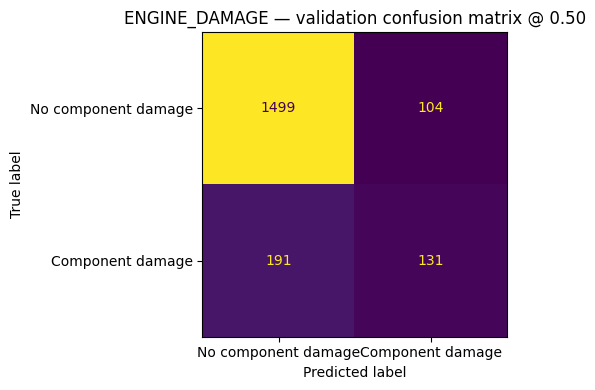

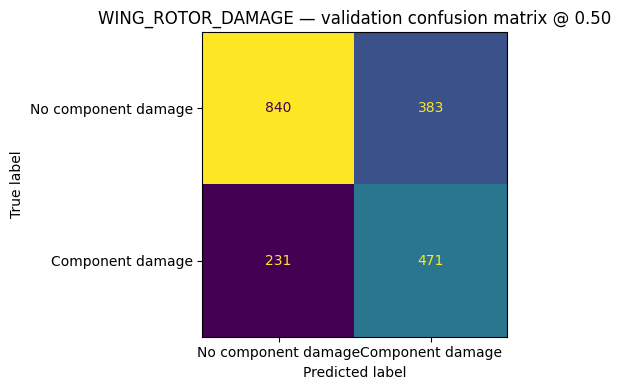

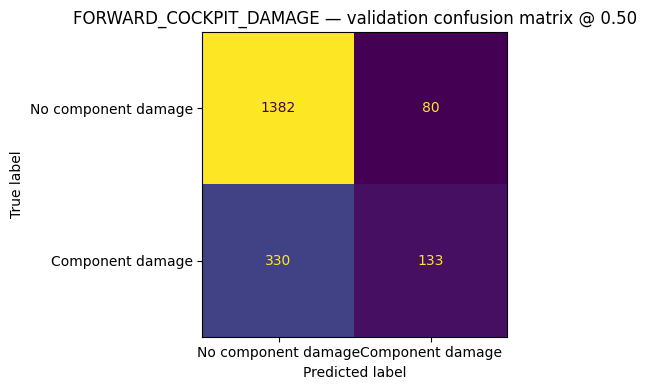

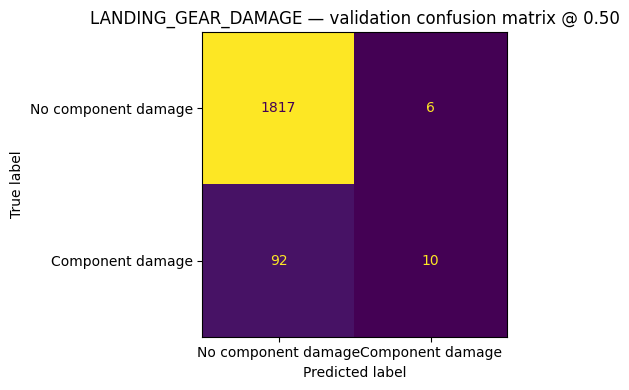

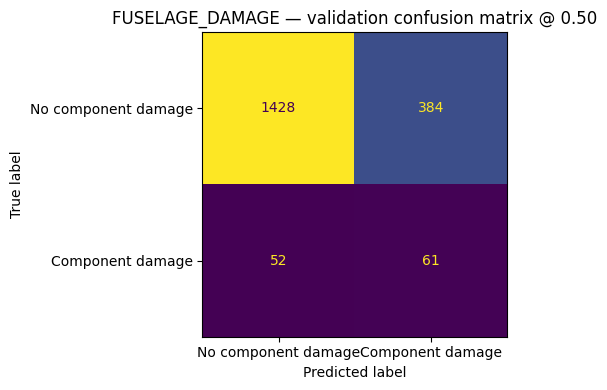

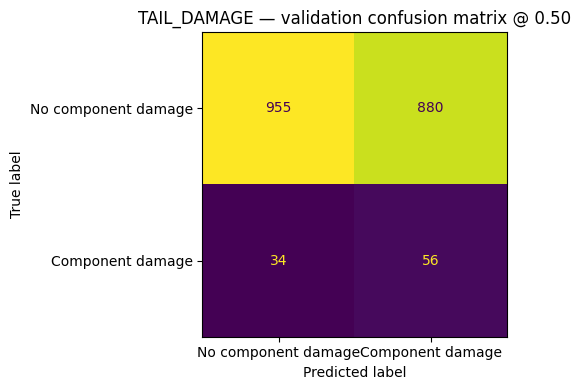

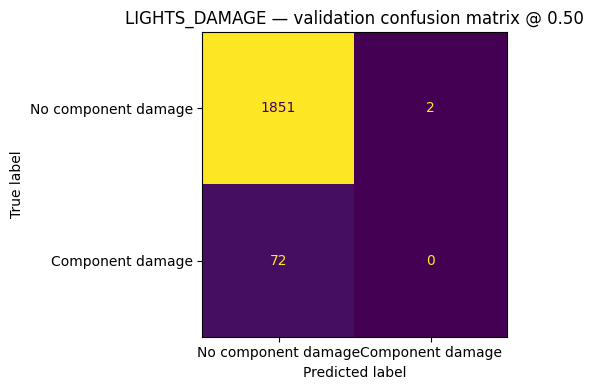

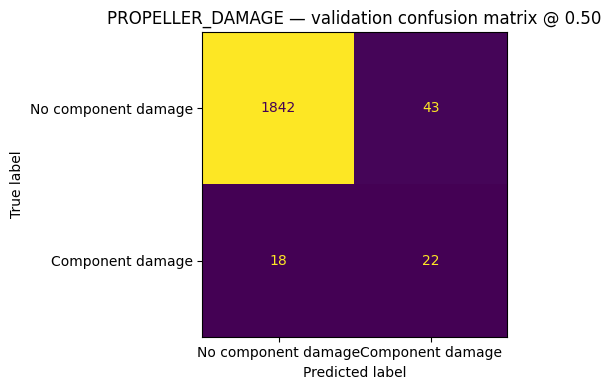

In [24]:
for target, candidate in SELECTED_BASE_CANDIDATES.items():
    info = fitted_candidates[candidate]
    y_val = validation_df[target].to_numpy()
    prob = validation_predictions[candidate].to_numpy()
    pred = (prob >= 0.50).astype(int)

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y_val, pred, labels=[0, 1]),
        display_labels=["No component damage", "Component damage"],
    ).plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(f"{target} — validation confusion matrix @ 0.50")
    plt.tight_layout()
    plt.show()


# 25. Forward calibration experiment inside 2019–2021

The selected base classifier remains trained only on 1990–2018. Calibration follows the same forward logic as Notebook 07:

- **2019:** fit the calibration mapping;
- **2020–2021:** compare raw, sigmoid, and isotonic probabilities.

Calibration methods are compared using forward 2020–2021 predictions after fitting the calibration mapping on 2019. Selection follows a predefined lexicographic rule: the method with the lowest Brier score is selected, with log loss used as a secondary criterion when necessary. The uncalibrated model remains one of the candidate methods and may therefore be retained when it provides the best Brier score. Because this procedure prioritizes Brier score, improvements in Brier score do not necessarily imply simultaneous improvements in log loss; both metrics are consequently reported and discussed.


In [25]:
class BinaryProbabilityCalibrator:
    def __init__(self, method="sigmoid"):
        if method not in {"sigmoid", "isotonic"}:
            raise ValueError("method must be 'sigmoid' or 'isotonic'")
        self.method = method
        self.model = None

    def fit(self, raw_probabilities, y):
        p = np.asarray(raw_probabilities, dtype=float)
        y = np.asarray(y, dtype=int)
        if self.method == "sigmoid":
            self.model = LogisticRegression(solver="lbfgs", random_state=SEED)
            self.model.fit(p.reshape(-1, 1), y)
        else:
            self.model = IsotonicRegression(out_of_bounds="clip")
            self.model.fit(p, y)
        return self

    def predict(self, raw_probabilities):
        p = np.asarray(raw_probabilities, dtype=float)
        if self.method == "sigmoid":
            return self.model.predict_proba(p.reshape(-1, 1))[:, 1]
        return np.asarray(self.model.predict(p), dtype=float)

cal_fit_df = validation_df.loc[validation_df["INCIDENT_YEAR"].eq(2019)].copy()
cal_eval_df = validation_df.loc[validation_df["INCIDENT_YEAR"].between(2020, 2021)].copy()

calibration_rows = []
calibration_objects = {}
calibration_eval_probabilities = {}

for target, candidate in SELECTED_BASE_CANDIDATES.items():
    info = fitted_candidates[candidate]
    pipe = info["pipeline"]
    features = info["features"]

    raw_fit = pipe.predict_proba(cal_fit_df[features])[:, 1]
    raw_eval = pipe.predict_proba(cal_eval_df[features])[:, 1]
    y_fit = cal_fit_df[target].to_numpy()
    y_eval = cal_eval_df[target].to_numpy()

    raw_metrics = evaluate_binary_probabilities(y_eval, raw_eval)
    calibration_rows.append({"target": target, "method": "raw", **raw_metrics})
    calibration_eval_probabilities[(target, "raw")] = raw_eval

    for method in ["sigmoid", "isotonic"]:
        calibrator = BinaryProbabilityCalibrator(method=method).fit(raw_fit, y_fit)
        calibrated_eval = calibrator.predict(raw_eval)
        metrics = evaluate_binary_probabilities(y_eval, calibrated_eval)
        calibration_rows.append({"target": target, "method": method, **metrics})
        calibration_objects[(target, method)] = calibrator
        calibration_eval_probabilities[(target, method)] = calibrated_eval

calibration_results = pd.DataFrame(calibration_rows).sort_values(
    ["target", "brier", "log_loss"], ascending=[True, True, True]
)
display(calibration_results)
calibration_results.to_csv(OUTPUT_DIR / "component_forward_calibration_metrics.csv", index=False)


,target,method,positive_rate,pr_auc,roc_auc,precision,recall,f1,balanced_accuracy,brier,log_loss,threshold
2,ENGINE_DAMAGE,isotonic,0.175000,0.487215,0.835186,0.637681,0.216749,0.323529,0.595313,0.111966,0.410918,0.5
1,ENGINE_DAMAGE,sigmoid,0.175000,0.503365,0.834777,0.614035,0.172414,0.269231,0.574713,0.113338,0.363443,0.5
0,ENGINE_DAMAGE,raw,0.175000,0.503365,0.834777,0.590604,0.433498,0.500000,0.684878,0.114221,0.361404,0.5
7,FORWARD_COCKPIT_DAMAGE,sigmoid,0.237069,0.451742,0.713126,0.550847,0.236364,0.330789,0.588238,0.159410,0.493029,0.5
6,FORWARD_COCKPIT_DAMAGE,raw,0.237069,0.451742,0.713126,0.557252,0.265455,0.359606,0.599959,0.159925,0.494686,0.5
8,FORWARD_COCKPIT_DAMAGE,isotonic,0.237069,0.405880,0.698028,0.559006,0.327273,0.412844,0.623523,0.164555,0.679384,0.5
13,FUSELAGE_DAMAGE,sigmoid,0.056034,0.163599,0.698862,0.000000,0.000000,0.000000,0.500000,0.051567,0.205991,0.5
14,FUSELAGE_DAMAGE,isotonic,0.056034,0.143638,0.697197,0.250000,0.030769,0.054795,0.512645,0.053973,0.353013,0.5
12,FUSELAGE_DAMAGE,raw,0.056034,0.163599,0.698862,0.125475,0.507692,0.201220,0.648823,0.188935,0.566016,0.5
9,LANDING_GEAR_DAMAGE,raw,0.054310,0.242551,0.714257,0.615385,0.126984,0.210526,0.561213,0.047009,0.188041,0.5


# 26. Select calibration method per target

The raw model remains an explicit option. Calibration is not assumed to improve every target.


In [26]:
SELECTED_CALIBRATION_METHODS = {}
calibration_selection_rows = []

for target in MODEL_TARGETS:
    target_cal = calibration_results.loc[calibration_results["target"].eq(target)].copy()
    target_cal = target_cal.sort_values(["brier", "log_loss"], ascending=[True, True])
    selected = target_cal.iloc[0]["method"]
    SELECTED_CALIBRATION_METHODS[target] = selected
    calibration_selection_rows.append(target_cal.iloc[0].to_dict())

calibration_selection_table = pd.DataFrame(calibration_selection_rows)
display(calibration_selection_table)
calibration_selection_table.to_csv(OUTPUT_DIR / "selected_component_calibration.csv", index=False)
print(SELECTED_CALIBRATION_METHODS)


,target,method,positive_rate,pr_auc,roc_auc,precision,recall,f1,balanced_accuracy,brier,log_loss,threshold
0,ENGINE_DAMAGE,isotonic,0.175000,0.487215,0.835186,0.637681,0.216749,0.323529,0.595313,0.111966,0.410918,0.5
1,WING_ROTOR_DAMAGE,sigmoid,0.368103,0.645124,0.760359,0.685315,0.459016,0.549790,0.668117,0.188508,0.559359,0.5
2,FORWARD_COCKPIT_DAMAGE,sigmoid,0.237069,0.451742,0.713126,0.550847,0.236364,0.330789,0.588238,0.159410,0.493029,0.5
3,LANDING_GEAR_DAMAGE,raw,0.054310,0.242551,0.714257,0.615385,0.126984,0.210526,0.561213,0.047009,0.188041,0.5
4,FUSELAGE_DAMAGE,sigmoid,0.056034,0.163599,0.698862,0.000000,0.000000,0.000000,0.500000,0.051567,0.205991,0.5
5,TAIL_DAMAGE,isotonic,0.042241,0.064619,0.623680,0.000000,0.000000,0.000000,0.500000,0.040192,0.170463,0.5
6,LIGHTS_DAMAGE,isotonic,0.042241,0.078709,0.630688,0.333333,0.040816,0.072727,0.518608,0.040029,0.277681,0.5
7,PROPELLER_DAMAGE,isotonic,0.022414,0.314967,0.837759,0.636364,0.269231,0.378378,0.632852,0.017542,0.234706,0.5


{'ENGINE_DAMAGE': 'isotonic', 'WING_ROTOR_DAMAGE': 'sigmoid', 'FORWARD_COCKPIT_DAMAGE': 'sigmoid', 'LANDING_GEAR_DAMAGE': 'raw', 'FUSELAGE_DAMAGE': 'sigmoid', 'TAIL_DAMAGE': 'isotonic', 'LIGHTS_DAMAGE': 'isotonic', 'PROPELLER_DAMAGE': 'isotonic'}


### Calibration interpretation

Forward calibration improves probability quality for several targets, although the preferred method differs by outcome. Sigmoid calibration is selected for wing/rotor, forward cockpit, and fuselage damage, while landing gear retains the raw model. Isotonic calibration is selected by the predefined Brier-first rule for engine, tail, lights, and propeller damage.

Calibration results also reveal an important trade-off between proper scoring rules. For some rare targets, particularly propeller and lights damage, isotonic calibration obtains the lowest Brier score but a higher log loss than sigmoid calibration. The selected calibration method should therefore be interpreted as the method preferred under the notebook's predefined Brier-first selection rule rather than as a method that necessarily dominates all alternatives across every proper scoring metric.



# 27. Calibration plots

Each plot compares predicted probability bins with the observed component-damage rate on 2020–2021. The diagonal represents perfect calibration.


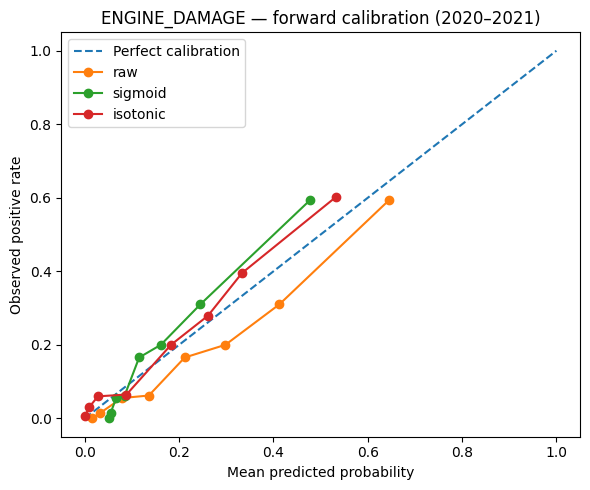

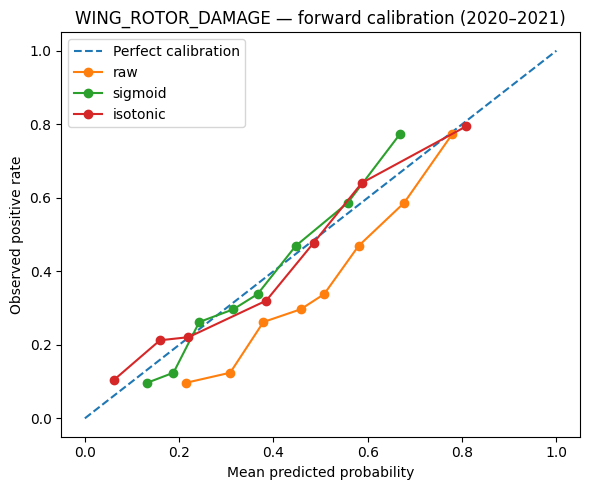

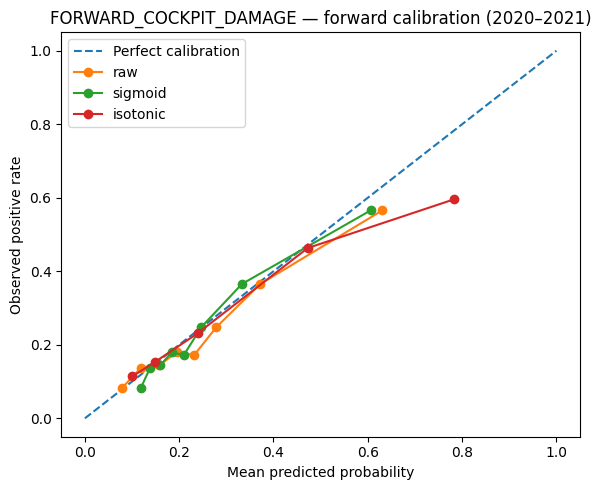

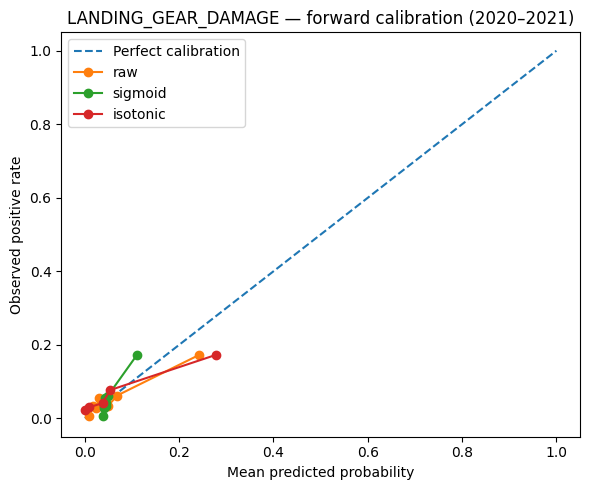

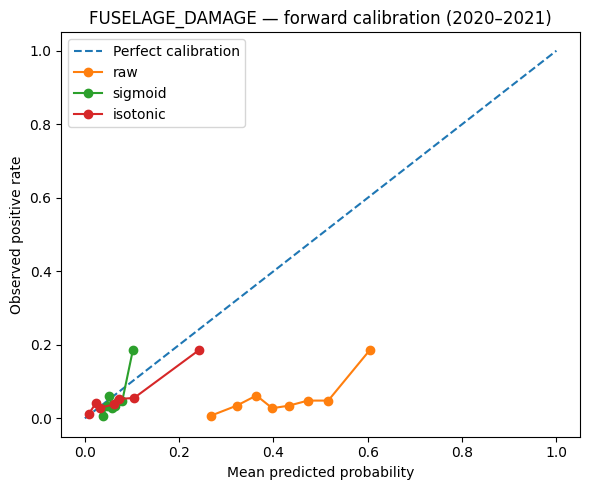

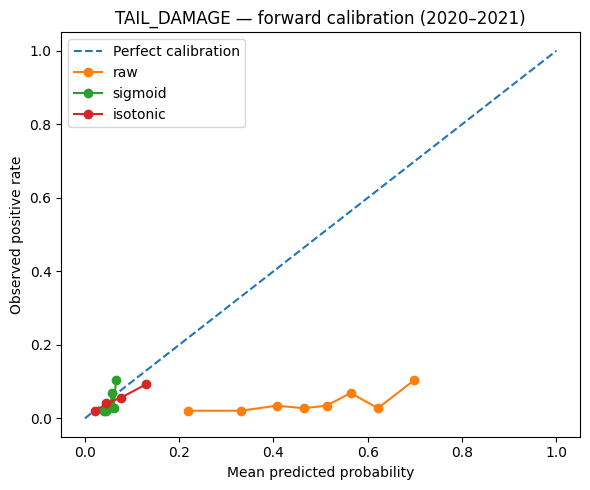

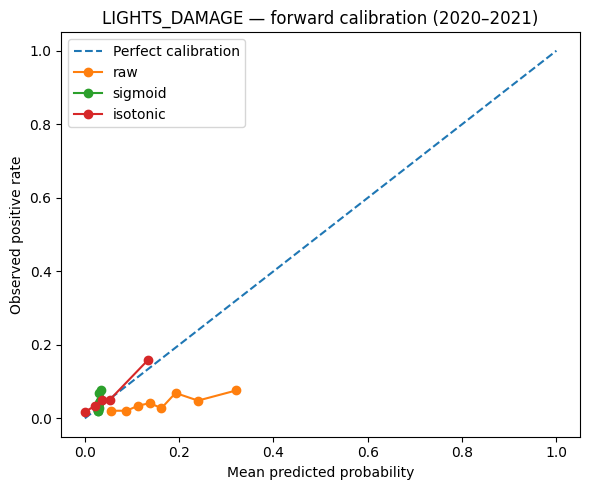

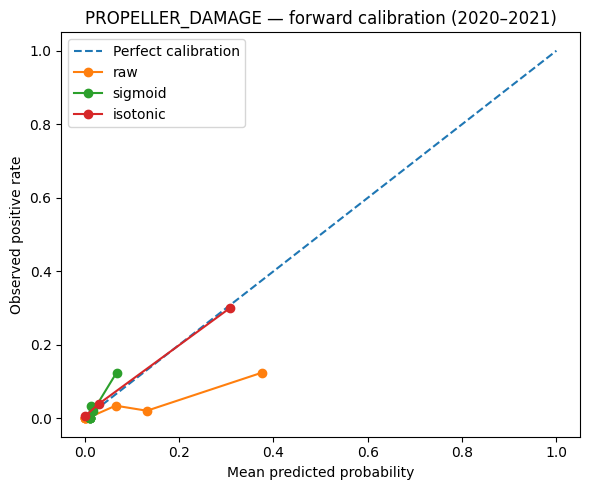

In [27]:
for target in MODEL_TARGETS:
    y_eval = cal_eval_df[target].to_numpy()
    methods = ["raw", "sigmoid", "isotonic"]

    plt.figure(figsize=(6, 5))
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")

    for method in methods:
        prob = calibration_eval_probabilities[(target, method)]
        frac_pos, mean_pred = calibration_curve(y_eval, prob, n_bins=8, strategy="quantile")
        plt.plot(mean_pred, frac_pos, marker="o", label=method)

    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed positive rate")
    plt.title(f"{target} — forward calibration (2020–2021)")
    plt.legend()
    plt.tight_layout()
    plt.show()


# 28. Threshold exploration on forward 2020–2021 probabilities

Thresholds are for classification summaries and interface flags; Monte Carlo consumes probabilities directly. The notebook therefore does **not** optimize a threshold as if it were the primary scientific output.

For reproducibility, the automatic threshold rule selects the threshold with the highest F1 on 2020–2021 among `0.10`–`0.90`. Recall and precision are saved so a later operational application can choose a different trade-off without retraining the probability model.


In [28]:
threshold_rows = []
SELECTED_THRESHOLDS = {}

for target in MODEL_TARGETS:
    selected_method = SELECTED_CALIBRATION_METHODS[target]
    prob = calibration_eval_probabilities[(target, selected_method)]
    y_eval = cal_eval_df[target].to_numpy()

    for threshold in np.round(np.arange(0.10, 0.91, 0.05), 2):
        metrics = evaluate_binary_probabilities(y_eval, prob, threshold=threshold)
        threshold_rows.append({"target": target, "calibration_method": selected_method, **metrics})

threshold_results = pd.DataFrame(threshold_rows)
threshold_results.to_csv(OUTPUT_DIR / "component_threshold_exploration.csv", index=False)

for target in MODEL_TARGETS:
    block = threshold_results.loc[threshold_results["target"].eq(target)].copy()
    block = block.sort_values(["f1", "recall", "precision"], ascending=[False, False, False])
    SELECTED_THRESHOLDS[target] = float(block.iloc[0]["threshold"])

print("Locked thresholds:", SELECTED_THRESHOLDS)
display(
    threshold_results.loc[
        threshold_results.apply(lambda r: r["threshold"] == SELECTED_THRESHOLDS[r["target"]], axis=1)
    ]
)


Locked thresholds: {'ENGINE_DAMAGE': 0.25, 'WING_ROTOR_DAMAGE': 0.3, 'FORWARD_COCKPIT_DAMAGE': 0.25, 'LANDING_GEAR_DAMAGE': 0.2, 'FUSELAGE_DAMAGE': 0.1, 'TAIL_DAMAGE': 0.1, 'LIGHTS_DAMAGE': 0.1, 'PROPELLER_DAMAGE': 0.1}


,target,calibration_method,positive_rate,pr_auc,roc_auc,precision,recall,f1,balanced_accuracy,brier,log_loss,threshold
3,ENGINE_DAMAGE,isotonic,0.175000,0.487215,0.835186,0.450172,0.645320,0.530364,0.739066,0.111966,0.410918,0.25
21,WING_ROTOR_DAMAGE,sigmoid,0.368103,0.645124,0.760359,0.502140,0.824356,0.624113,0.674115,0.188508,0.559359,0.30
37,FORWARD_COCKPIT_DAMAGE,sigmoid,0.237069,0.451742,0.713126,0.437143,0.556364,0.489600,0.666882,0.159410,0.493029,0.25
53,LANDING_GEAR_DAMAGE,raw,0.054310,0.242551,0.714257,0.327869,0.317460,0.322581,0.640043,0.047009,0.188041,0.20
68,FUSELAGE_DAMAGE,sigmoid,0.056034,0.163599,0.698862,0.223881,0.230769,0.227273,0.591640,0.051567,0.205991,0.10
85,TAIL_DAMAGE,isotonic,0.042241,0.064619,0.623680,0.093023,0.163265,0.118519,0.546529,0.040192,0.170463,0.10
102,LIGHTS_DAMAGE,isotonic,0.042241,0.078709,0.630688,0.333333,0.040816,0.072727,0.518608,0.040029,0.277681,0.10
119,PROPELLER_DAMAGE,isotonic,0.022414,0.314967,0.837759,0.342857,0.461538,0.393443,0.720628,0.017542,0.234706,0.10


### Threshold interpretation

The default 0.50 threshold is unsuitable for several rare component outcomes because it produces very low or zero recall. Threshold exploration therefore selects lower reporting thresholds ranging from 0.10 to 0.30.

The locked thresholds are 0.25 for engine and forward cockpit damage, 0.30 for wing/rotor damage, 0.20 for landing gear damage, and 0.10 for fuselage, tail, lights, and propeller damage.

Lowering these thresholds generally increases recall at the cost of additional false positives. This trade-off is particularly important for rare outcomes, where a 0.50 cutoff is excessively conservative. These thresholds affect only binary classification summaries and confusion matrices; Monte Carlo simulation should consume the calibrated probabilities directly rather than the thresholded classes.

# 29. Lock the final component systems before opening 2022–2024

At this point, freeze for every viable target:

1. target definition;
2. feature set;
3. model family;
4. hyperparameters;
5. calibration choice; and
6. classification threshold.

If a target clearly fails during 2019–2021 development validation, it can be downgraded **before** the final test by adding it to `PRETEST_DESCRIPTIVE_ONLY` with a written rationale.


In [29]:
PRETEST_DESCRIPTIVE_ONLY = {
    # Example: "PROPELLER_DAMAGE": "Insufficient validation discrimination / unstable recall."
}

FINAL_TEST_TARGETS = [t for t in MODEL_TARGETS if t not in PRETEST_DESCRIPTIVE_ONLY]

locked_configuration_rows = []
final_calibrators = {}

for target in FINAL_TEST_TARGETS:
    candidate = SELECTED_BASE_CANDIDATES[target]
    info = fitted_candidates[candidate]
    method = SELECTED_CALIBRATION_METHODS[target]

    # Refit the chosen calibrator on all 2019–2021 development-validation probabilities.
    raw_val_all = info["pipeline"].predict_proba(validation_df[info["features"]])[:, 1]
    y_val_all = validation_df[target].to_numpy()

    if method == "raw":
        final_calibrators[target] = None
    else:
        final_calibrators[target] = BinaryProbabilityCalibrator(method=method).fit(raw_val_all, y_val_all)

    locked_configuration_rows.append({
        "target": target,
        "candidate": candidate,
        "model": info["model"],
        "feature_set": info["feature_set"],
        "features": json.dumps(info["features"]),
        "best_params": json.dumps(info["best_params"], sort_keys=True),
        "calibration_method": method,
        "classification_threshold": SELECTED_THRESHOLDS[target],
        "status_before_final_test": "LOCKED_FOR_FINAL_TEST",
    })

locked_configuration = pd.DataFrame(locked_configuration_rows)
display(locked_configuration)
locked_configuration.to_csv(OUTPUT_DIR / "component_locked_configuration.csv", index=False)


,target,candidate,model,feature_set,features,best_params,calibration_method,classification_threshold,status_before_final_test
0,ENGINE_DAMAGE,ENGINE_DAMAGE__xgboost__extended_geographic,xgboost,extended_geographic,"[""SEASON"", ""MONTH_SIN"", ""MONTH_COS"", ""WILDLIFE...","{""model__colsample_bytree"": 0.821210123594367,...",isotonic,0.25,LOCKED_FOR_FINAL_TEST
1,WING_ROTOR_DAMAGE,WING_ROTOR_DAMAGE__random_forest__extended_geo...,random_forest,extended_geographic,"[""SEASON"", ""MONTH_SIN"", ""MONTH_COS"", ""WILDLIFE...","{""model__class_weight"": ""balanced"", ""model__ma...",sigmoid,0.30,LOCKED_FOR_FINAL_TEST
2,FORWARD_COCKPIT_DAMAGE,FORWARD_COCKPIT_DAMAGE__xgboost__extended_geog...,xgboost,extended_geographic,"[""SEASON"", ""MONTH_SIN"", ""MONTH_COS"", ""WILDLIFE...","{""model__colsample_bytree"": 0.8487203795438925...",sigmoid,0.25,LOCKED_FOR_FINAL_TEST
3,LANDING_GEAR_DAMAGE,LANDING_GEAR_DAMAGE__random_forest__airport_aware,random_forest,airport_aware,"[""SEASON"", ""MONTH_SIN"", ""MONTH_COS"", ""WILDLIFE...","{""model__class_weight"": null, ""model__max_dept...",raw,0.20,LOCKED_FOR_FINAL_TEST
4,FUSELAGE_DAMAGE,FUSELAGE_DAMAGE__random_forest__airport_aware,random_forest,airport_aware,"[""SEASON"", ""MONTH_SIN"", ""MONTH_COS"", ""WILDLIFE...","{""model__class_weight"": ""balanced"", ""model__ma...",sigmoid,0.10,LOCKED_FOR_FINAL_TEST
5,TAIL_DAMAGE,TAIL_DAMAGE__logistic__airport_aware,logistic,airport_aware,"[""SEASON"", ""MONTH_SIN"", ""MONTH_COS"", ""WILDLIFE...","{""model__C"": 0.04203965712872512, ""model__clas...",isotonic,0.10,LOCKED_FOR_FINAL_TEST
6,LIGHTS_DAMAGE,LIGHTS_DAMAGE__xgboost__extended_geographic,xgboost,extended_geographic,"[""SEASON"", ""MONTH_SIN"", ""MONTH_COS"", ""WILDLIFE...","{""model__colsample_bytree"": 0.8796976554358416...",isotonic,0.10,LOCKED_FOR_FINAL_TEST
7,PROPELLER_DAMAGE,PROPELLER_DAMAGE__xgboost__airport_aware,xgboost,airport_aware,"[""SEASON"", ""MONTH_SIN"", ""MONTH_COS"", ""WILDLIFE...","{""model__colsample_bytree"": 0.9029132901220702...",isotonic,0.10,LOCKED_FOR_FINAL_TEST


# 30. FINAL TEST UNLOCK — 2022–2024

> **Do not change target definitions, hyperparameters, feature sets, calibration methods, or thresholds after running this section based on the test results.**

The locked final test answers whether each component probability system generalizes to later reporting years.


In [30]:
final_test_rows = []
final_test_predictions = test_df[["INDEX_NR", "INCIDENT_YEAR"]].copy()

for target in FINAL_TEST_TARGETS:
    candidate = SELECTED_BASE_CANDIDATES[target]
    info = fitted_candidates[candidate]
    features = info["features"]
    raw_prob = info["pipeline"].predict_proba(test_df[features])[:, 1]

    calibrator = final_calibrators[target]
    prob = raw_prob if calibrator is None else calibrator.predict(raw_prob)
    threshold = SELECTED_THRESHOLDS[target]
    metrics = evaluate_binary_probabilities(test_df[target].to_numpy(), prob, threshold=threshold)
    metrics.update({
        "target": target,
        "candidate": candidate,
        "calibration_method": SELECTED_CALIBRATION_METHODS[target],
    })
    final_test_rows.append(metrics)
    final_test_predictions[f"{target}_probability"] = prob
    final_test_predictions[f"{target}_observed"] = test_df[target].to_numpy()

final_test_results = pd.DataFrame(final_test_rows).sort_values("pr_auc", ascending=False)
display(final_test_results)
final_test_results.to_csv(OUTPUT_DIR / "component_final_test_metrics.csv", index=False)
final_test_predictions.to_csv(OUTPUT_DIR / "component_final_test_predictions.csv", index=False)


,positive_rate,pr_auc,roc_auc,precision,recall,f1,balanced_accuracy,brier,log_loss,threshold,target,candidate,calibration_method
1,0.334817,0.573060,0.748416,0.487402,0.746011,0.589595,0.675549,0.185546,0.549882,0.30,WING_ROTOR_DAMAGE,WING_ROTOR_DAMAGE__random_forest__extended_geo...,sigmoid
2,0.238646,0.461147,0.693625,0.442105,0.470149,0.455696,0.642092,0.160650,0.497458,0.25,FORWARD_COCKPIT_DAMAGE,FORWARD_COCKPIT_DAMAGE__xgboost__extended_geog...,sigmoid
0,0.204363,0.437164,0.791087,0.437700,0.596950,0.505069,0.699986,0.136330,0.434630,0.25,ENGINE_DAMAGE,ENGINE_DAMAGE__xgboost__extended_geographic,isotonic
7,0.023152,0.272160,0.941199,0.279570,0.500000,0.358621,0.734731,0.019406,0.086309,0.10,PROPELLER_DAMAGE,PROPELLER_DAMAGE__xgboost__airport_aware,isotonic
3,0.040071,0.247950,0.778391,0.360465,0.344444,0.352273,0.659467,0.033866,0.141198,0.20,LANDING_GEAR_DAMAGE,LANDING_GEAR_DAMAGE__random_forest__airport_aware,raw
4,0.053428,0.089879,0.650321,0.103448,0.125000,0.113208,0.531926,0.049951,0.202077,0.10,FUSELAGE_DAMAGE,FUSELAGE_DAMAGE__random_forest__airport_aware,sigmoid
6,0.048531,0.074276,0.616686,0.108108,0.110092,0.109091,0.531883,0.045944,0.218863,0.10,LIGHTS_DAMAGE,LIGHTS_DAMAGE__xgboost__extended_geographic,isotonic
5,0.049866,0.073270,0.588807,0.079268,0.116071,0.094203,0.522656,0.047415,0.225028,0.10,TAIL_DAMAGE,TAIL_DAMAGE__logistic__airport_aware,isotonic


### Final-test interpretation

The locked 2022–2024 test confirms that several component models generalize meaningfully to future reporting years.

Wing/rotor damage achieves PR-AUC 0.573 compared with a prevalence baseline of 0.335, with recall 0.746 and F1 0.590. Engine damage achieves PR-AUC 0.437 compared with prevalence 0.204, with recall 0.597 and F1 0.505. Forward cockpit damage achieves PR-AUC 0.461 compared with prevalence 0.239, with recall 0.470 and F1 0.456. These results provide useful but imperfect temporal discrimination.

Landing gear damage performs strongly relative to its rarity: PR-AUC is 0.248 compared with prevalence 0.040, approximately six times its prevalence reference. Recall is 0.344 and precision 0.360.

Propeller damage also shows unusually strong discrimination relative to prevalence. PR-AUC reaches 0.272 compared with prevalence of only 0.023, with ROC-AUC 0.941, recall 0.500, and precision 0.280. This represents the largest proportional improvement over a no-skill PR-AUC baseline, although only 52 positive propeller cases occur in the final test, so uncertainty remains higher than for the major component groups.

Fuselage, tail, and lights damage show substantially weaker practical performance. Their final PR-AUC values are only 0.090, 0.073, and 0.074, respectively, and balanced accuracy remains close to 0.50 for tail and lights. Their precision, recall, and F1 scores are also low. Although their PR-AUC values exceed their prevalence baselines slightly, the improvement is insufficiently strong and consistent to justify repeated probabilistic sampling in the simulation.

No model is retuned after observing these results. The final test is used only to determine whether the previously locked component models are sufficiently reliable for downstream use.

# 31. Final-test confusion matrices


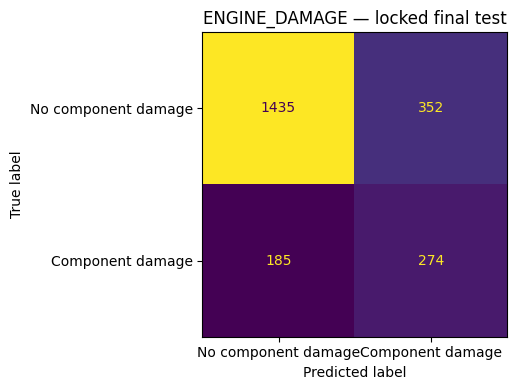

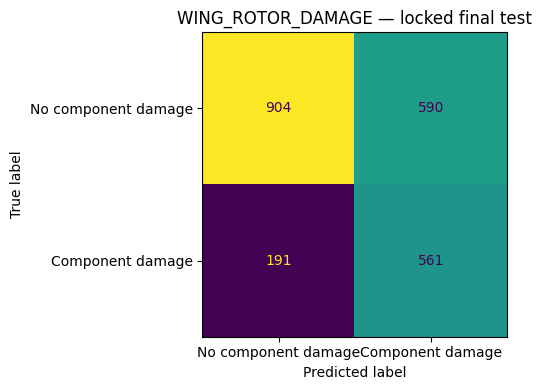

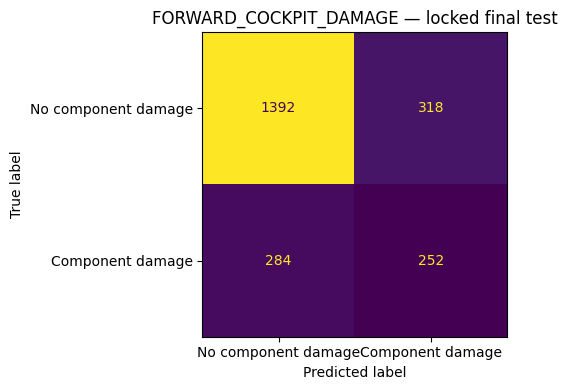

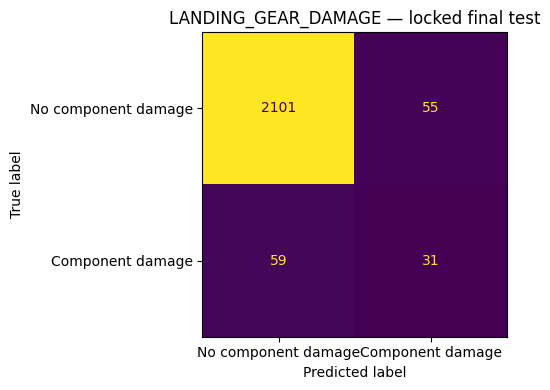

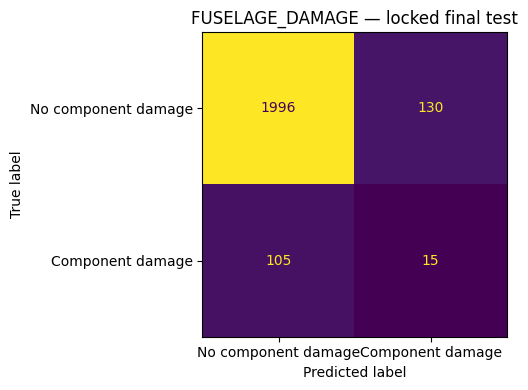

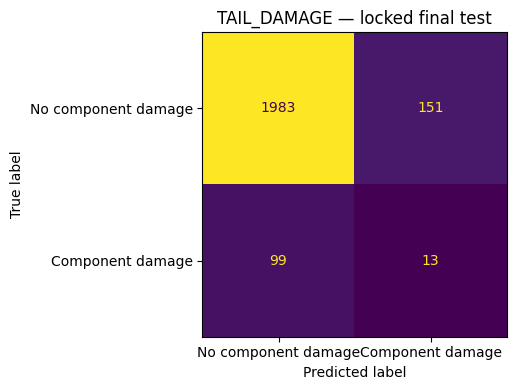

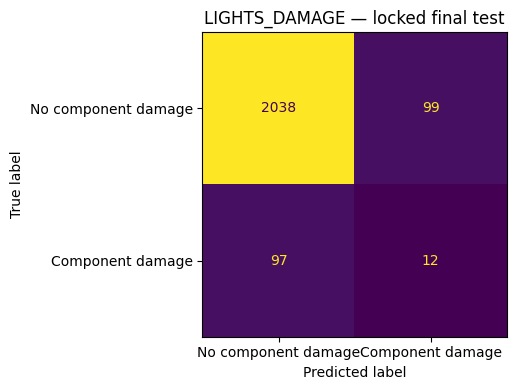

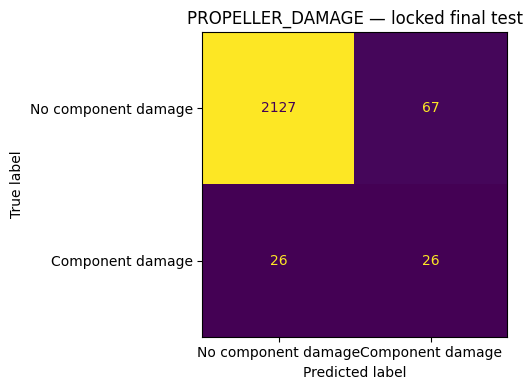

In [31]:
for target in FINAL_TEST_TARGETS:
    prob = final_test_predictions[f"{target}_probability"].to_numpy()
    y = final_test_predictions[f"{target}_observed"].to_numpy()
    pred = (prob >= SELECTED_THRESHOLDS[target]).astype(int)

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y, pred, labels=[0, 1]),
        display_labels=["No component damage", "Component damage"],
    ).plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(f"{target} — locked final test")
    plt.tight_layout()
    plt.show()


# 32. Final-test performance by year

Aggregate 2022–2024 results can hide drift. Year-level results are diagnostic only and cannot be used to retune the locked models.


In [32]:
year_rows = []
for target in FINAL_TEST_TARGETS:
    for year in sorted(test_df["INCIDENT_YEAR"].unique()):
        m = test_df["INCIDENT_YEAR"].eq(year).to_numpy()
        y = final_test_predictions.loc[m, f"{target}_observed"].to_numpy()
        p = final_test_predictions.loc[m, f"{target}_probability"].to_numpy()
        if len(np.unique(y)) < 2:
            # Keep counts even if ranking metrics are undefined.
            year_rows.append({
                "target": target,
                "year": int(year),
                "rows": int(m.sum()),
                "positive": int(y.sum()),
                "positive_rate": float(y.mean()),
                "pr_auc": np.nan,
                "roc_auc": np.nan,
                "precision": np.nan,
                "recall": np.nan,
                "f1": np.nan,
                "brier": float(brier_score_loss(y, p)),
                "log_loss": np.nan,
            })
            continue

        metrics = evaluate_binary_probabilities(y, p, threshold=SELECTED_THRESHOLDS[target])
        year_rows.append({"target": target, "year": int(year), "rows": int(m.sum()), "positive": int(y.sum()), **metrics})

year_results = pd.DataFrame(year_rows)
display(year_results)
year_results.to_csv(OUTPUT_DIR / "component_final_test_by_year.csv", index=False)


,target,year,rows,positive,positive_rate,pr_auc,roc_auc,precision,recall,f1,balanced_accuracy,brier,log_loss,threshold
0,ENGINE_DAMAGE,2022,702,117,0.166667,0.370576,0.768164,0.364641,0.564103,0.442953,0.683761,0.125993,0.437553,0.25
1,ENGINE_DAMAGE,2023,721,172,0.238558,0.506957,0.798587,0.485577,0.587209,0.531579,0.696155,0.148030,0.451410,0.25
2,ENGINE_DAMAGE,2024,823,170,0.206561,0.444711,0.800563,0.451477,0.629412,0.525799,0.715165,0.134897,0.417436,0.25
3,WING_ROTOR_DAMAGE,2022,702,235,0.334758,0.587564,0.757943,0.487179,0.727660,0.583618,0.671110,0.183955,0.544436,0.30
4,WING_ROTOR_DAMAGE,2023,721,227,0.314840,0.557724,0.748181,0.466125,0.757709,0.577181,0.679462,0.180116,0.539542,0.30
5,WING_ROTOR_DAMAGE,2024,823,290,0.352369,0.580443,0.742796,0.505800,0.751724,0.604716,0.676050,0.191659,0.563585,0.30
6,FORWARD_COCKPIT_DAMAGE,2022,702,170,0.242165,0.477249,0.719068,0.444444,0.517647,0.478261,0.655440,0.162233,0.498094,0.25
7,FORWARD_COCKPIT_DAMAGE,2023,721,178,0.246879,0.513276,0.708398,0.469945,0.483146,0.476454,0.652254,0.159068,0.494001,0.25
8,FORWARD_COCKPIT_DAMAGE,2024,823,188,0.228433,0.404459,0.655847,0.412698,0.414894,0.413793,0.620045,0.160685,0.499945,0.25
9,LANDING_GEAR_DAMAGE,2022,702,36,0.051282,0.217533,0.707207,0.307692,0.222222,0.258065,0.597598,0.045327,0.183082,0.20


### Year-by-year interpretation

Year-by-year evaluation supports the overall final-test conclusions. Wing/rotor damage remains stable across 2022–2024, with PR-AUC between approximately 0.56 and 0.59. Engine damage also remains useful, ranging from approximately 0.37 to 0.51, while forward cockpit performance decreases somewhat in 2024 but remains above prevalence.

Landing gear performance varies because annual positive counts are small, ranging from 24 to 36 cases, but PR-AUC remains substantially above annual prevalence in all three years.

Propeller damage has only 16–18 positive observations per year, so annual estimates are necessarily uncertain. Nevertheless, PR-AUC remains well above its approximately 2% prevalence in every test year, while ROC-AUC remains above 0.93.

In contrast, fuselage, tail, and lights damage provide consistently weak discrimination. Their annual PR-AUC values remain close to their already low prevalence rates, and classification performance is limited. This pattern suggests genuine predictive weakness rather than failure confined to one anomalous year.

# 33. Decision gate for simulation

There is deliberately **no universal PR-AUC cutoff**. Each target must be judged relative to its prevalence baseline and across several dimensions.

### Evidence supporting `MODELLED / RETAIN`

A component can be retained when, taken together:

- PR-AUC is meaningfully above the target prevalence/prior baseline;
- discrimination remains useful on 2019–2021 and 2022–2024;
- positive recall/precision are not degenerate at the locked reporting threshold;
- Brier score/log loss indicate usable probability quality;
- calibration is acceptable or improves forward probability quality;
- results are not driven by a single unstable year;
- the target has a clear component interpretation.

### Evidence supporting `DESCRIPTIVE ONLY`

Use when the component is substantively meaningful but prediction is too weak, unstable, sparse, or poorly calibrated for repeated Monte Carlo sampling.

### Evidence supporting `EXCLUDED`

Use when the field is not a stable component target, is contaminated by leakage/definition problems, or has no defensible role in scenario simulation.



In [36]:
COMPONENT_FINAL_DECISIONS = {
    "ENGINE_DAMAGE": "MODELLED",
    "FORWARD_COCKPIT_DAMAGE": "MODELLED",
    "WING_ROTOR_DAMAGE": "MODELLED",
    "PROPELLER_DAMAGE": "MODELLED",
    "FUSELAGE_DAMAGE": "DESCRIPTIVE ONLY",
    "LANDING_GEAR_DAMAGE": "MODELLED",
    "TAIL_DAMAGE": "DESCRIPTIVE ONLY",
    "LIGHTS_DAMAGE": "DESCRIPTIVE ONLY",
}

COMPONENT_FINAL_DECISIONS["OTHER"] = "EXCLUDED"


print(COMPONENT_FINAL_DECISIONS)


{'ENGINE_DAMAGE': 'MODELLED', 'FORWARD_COCKPIT_DAMAGE': 'MODELLED', 'WING_ROTOR_DAMAGE': 'MODELLED', 'PROPELLER_DAMAGE': 'MODELLED', 'FUSELAGE_DAMAGE': 'DESCRIPTIVE ONLY', 'LANDING_GEAR_DAMAGE': 'MODELLED', 'TAIL_DAMAGE': 'DESCRIPTIVE ONLY', 'LIGHTS_DAMAGE': 'DESCRIPTIVE ONLY', 'OTHER': 'EXCLUDED'}


### Final component decision

Five component outcomes are retained for downstream probabilistic modelling: engine damage, wing/rotor damage, forward cockpit damage, landing gear damage, and propeller damage.

Engine, wing/rotor, and forward cockpit damage have substantial sample support and retain useful discrimination across chronological validation and the locked 2022–2024 test. Landing gear damage has lower prevalence but demonstrates PR-AUC substantially above its prevalence baseline and useful future-year discrimination.

Propeller damage is also retained because its discrimination remains exceptionally strong relative to its approximately 2% prevalence, including a final-test PR-AUC of 0.272 and ROC-AUC of 0.941. However, only 52 positive propeller cases occur in the final test, and annual counts range from 16 to 18. Its downstream estimates must therefore be labelled as lower-support and more uncertain than those of the more frequent component groups.

Fuselage, tail, and lights damage are classified DESCRIPTIVE ONLY. Although models can be fitted and their PR-AUC values sometimes exceed prevalence, their locked future-year discrimination and classification behaviour are too weak to justify repeated Monte Carlo sampling.

`DAM_OTHER` remains EXCLUDED because it is a heterogeneous residual category without a stable component interpretation.

Notebook 10 is therefore permitted to consume calibrated probabilities only for engine, wing/rotor, forward cockpit, landing gear, and propeller damage. Component outcomes remain non-mutually-exclusive and should not be interpreted as a physical damage-propagation model.

## 33.1 Propagate final target decisions back to every original FAA component

After the group-level decision gate is completed, this table converts the outcome back to the original `DAM_*` fields so the checklist requirement is satisfied literally. If a grouped target fails, each source component represented by that target becomes `DESCRIPTIVE ONLY` for simulation purposes. `DAM_OTHER` remains `EXCLUDED` from predictive simulation.


In [38]:
# Important:
# A source field marked MODELLED here is not necessarily a standalone model.
# It may instead contribute to a retained pooled/grouped target such as ENGINE_DAMAGE.

final_original_component_rows = []

for component, (pre_status, model_target, rationale) in ORIGINAL_COMPONENT_DECISIONS.items():

    # DAM_OTHER is excluded because it is a heterogeneous residual category.
    if component == "DAM_OTHER":
        final_status = "EXCLUDED"
        final_reason = rationale

    # Any field without a modelling target remains descriptive only.
    elif model_target is None:
        final_status = "DESCRIPTIVE ONLY"
        final_reason = rationale

    else:
        group_decision = COMPONENT_FINAL_DECISIONS.get(model_target, "PENDING")

        if group_decision == "MODELLED":
            final_status = "MODELLED"

            # Make the pooled-engine interpretation explicit.
            if model_target == "ENGINE_DAMAGE":
                if component in {"DAM_ENG3", "DAM_ENG4"}:
                    final_reason = (
                        f"Retained only as a source field within the pooled {model_target} target. "
                        f"{component} was too sparse for reliable standalone modelling, so no "
                        "individual engine-position classifier was fitted."
                    )
                else:
                    final_reason = (
                        f"Retained as a source field within the pooled {model_target} target. "
                        "The final predictive model estimates whether any engine was damaged; "
                        f"it does not estimate {component} independently."
                    )

            # Forward cockpit is also a pooled target.
            elif model_target == "FORWARD_COCKPIT_DAMAGE":
                final_reason = (
                    f"Retained as a source field within the pooled {model_target} target. "
                    "The final model estimates damage to any represented forward/cockpit "
                    f"component rather than {component} independently."
                )

            # These targets correspond directly to one original FAA component.
            else:
                final_reason = (
                    f"Represented by retained binary target {model_target}. "
                    "This component passed the final simulation decision gate."
                )

        elif group_decision in {"DESCRIPTIVE ONLY", "EXCLUDED"}:
            final_status = "DESCRIPTIVE ONLY"
            final_reason = (
                f"Represented by {model_target}, which did not pass the final "
                "simulation decision gate. The original FAA field is retained "
                "for descriptive reporting but is not exported as a probability model."
            )

        else:
            final_status = "PENDING"
            final_reason = f"Awaiting final decision for grouped target {model_target}."

    final_original_component_rows.append({
        "component": component,
        "final_status": final_status,
        "model_target": model_target,
        "pre_modelling_status": pre_status,
        "final_rationale": final_reason,
    })


final_original_component_decisions = pd.DataFrame(
    final_original_component_rows
)

display(final_original_component_decisions)

final_original_component_decisions.to_csv(
    OUTPUT_DIR / "final_original_component_decisions.csv",
    index=False,
)


,component,final_status,model_target,pre_modelling_status,final_rationale
0,DAM_RAD,MODELLED,FORWARD_COCKPIT_DAMAGE,CANDIDATE VIA GROUP,Retained as a source field within the pooled F...
1,DAM_WINDSHLD,MODELLED,FORWARD_COCKPIT_DAMAGE,CANDIDATE VIA GROUP,Retained as a source field within the pooled F...
2,DAM_NOSE,MODELLED,FORWARD_COCKPIT_DAMAGE,CANDIDATE VIA GROUP,Retained as a source field within the pooled F...
3,DAM_ENG1,MODELLED,ENGINE_DAMAGE,CANDIDATE VIA GROUP,Retained as a source field within the pooled E...
4,DAM_ENG2,MODELLED,ENGINE_DAMAGE,CANDIDATE VIA GROUP,Retained as a source field within the pooled E...
5,DAM_ENG3,MODELLED,ENGINE_DAMAGE,CANDIDATE VIA GROUP,Retained only as a source field within the poo...
6,DAM_ENG4,MODELLED,ENGINE_DAMAGE,CANDIDATE VIA GROUP,Retained only as a source field within the poo...
7,DAM_PROP,MODELLED,PROPELLER_DAMAGE,CANDIDATE VIA GROUP,Represented by retained binary target PROPELLE...
8,DAM_WING_ROT,MODELLED,WING_ROTOR_DAMAGE,CANDIDATE VIA GROUP,Represented by retained binary target WING_ROT...
9,DAM_FUSE,DESCRIPTIVE ONLY,FUSELAGE_DAMAGE,CANDIDATE VIA GROUP,"Represented by FUSELAGE_DAMAGE, which did not ..."


# 34. Save only approved final component artifacts

Models classified as descriptive-only are **not** exported to `models/final/`.


In [39]:
# ============================================================
# 34. SAVE ONLY APPROVED FINAL COMPONENT ARTIFACTS
# ============================================================
#
# Only targets classified MODELLED are exported.
# Descriptive-only and excluded targets remain documented in
# the output tables but cannot accidentally be consumed by
# Notebook 10 as predictive systems.


# ------------------------------------------------------------
# 34.1 Validate final decisions
# ------------------------------------------------------------

ALLOWED_COMPONENT_DECISIONS = {
    "MODELLED",
    "DESCRIPTIVE ONLY",
    "EXCLUDED",
}

pending = [
    target
    for target in COMPONENT_GROUPS
    if COMPONENT_FINAL_DECISIONS.get(target) not in ALLOWED_COMPONENT_DECISIONS
]

if pending:
    raise RuntimeError(
        "Final component decisions are still missing or pending for: "
        + ", ".join(pending)
    )


# ------------------------------------------------------------
# 34.2 Record why each retained component passed the gate
# ------------------------------------------------------------
#
# These statements summarize the evidence already produced by
# chronological CV, 2019-2021 validation/calibration, and the
# locked 2022-2024 final test.
#
# They are metadata/documentation only. They do not change or
# retune any fitted model.

DECISION_RATIONALES = {
    "ENGINE_DAMAGE": (
        "Retained because the model showed useful discrimination relative to "
        "component prevalence across chronological validation and the locked "
        "future-year test, with substantial positive-class sample support."
    ),

    "WING_ROTOR_DAMAGE": (
        "Retained because discrimination remained useful and comparatively "
        "stable across chronological validation and the locked 2022-2024 test."
    ),

    "FORWARD_COCKPIT_DAMAGE": (
        "Retained because the grouped forward/cockpit target showed useful "
        "chronological discrimination and comparatively stable prevalence "
        "across the analytical periods."
    ),

    "LANDING_GEAR_DAMAGE": (
        "Retained despite low prevalence because PR-AUC remained substantially "
        "above the target prevalence reference during validation and later-year "
        "testing, providing evidence of useful predictive information."
    ),

    "PROPELLER_DAMAGE": (
        "Retained because discrimination was strong relative to its very low "
        "prevalence and remained above the no-skill reference in the locked "
        "future-year evaluation. The model is retained with an explicit "
        "low-support uncertainty warning."
    ),
}


# ------------------------------------------------------------
# 34.3 Support / uncertainty notes for downstream use
# ------------------------------------------------------------
#
# These notes travel inside each serialized artifact so that
# Notebook 10 does not need to infer model limitations from
# Notebook 08's narrative.

SUPPORT_NOTES = {
    "ENGINE_DAMAGE": (
        "Substantial component support. The target pools DAM_ENG1 through "
        "DAM_ENG4 and predicts any-engine involvement; it does not identify "
        "which individual engine position was damaged."
    ),

    "WING_ROTOR_DAMAGE": (
        "Strong component support relative to the other component outcomes. "
        "Retained for downstream conditional probability simulation."
    ),

    "FORWARD_COCKPIT_DAMAGE": (
        "This is a pooled outcome combining DAM_RAD, DAM_WINDSHLD, and DAM_NOSE. "
        "The probability therefore represents involvement of at least one of "
        "these forward/cockpit components, not a probability for each individual field."
    ),

    "LANDING_GEAR_DAMAGE": (
        "Lower-prevalence outcome. Retained because future-year discrimination "
        "remained meaningfully above prevalence, but estimates should still be "
        "presented with greater uncertainty than the most frequent component targets."
    ),

    "PROPELLER_DAMAGE": (
        "LOW-SUPPORT WARNING: retained because discrimination was strong relative "
        "to prevalence, but only 52 positive cases occur in the locked 2022-2024 "
        "final test and yearly positive counts are approximately 16-18. "
        "Downstream results should be labelled as lower-support and more uncertain."
    ),
}


# ------------------------------------------------------------
# 34.4 Optional final-test evidence summary stored as metadata
# ------------------------------------------------------------
#
# These numbers document the already-observed locked-test
# evidence. They are NOT used below to alter fitting,
# calibration, features, hyperparameters, or thresholds.

FINAL_TEST_EVIDENCE_SUMMARY = {
    "ENGINE_DAMAGE": {
        "pr_auc": 0.437,
        "test_prevalence": 0.204,
        "interpretation": (
            "Useful future-year discrimination above prevalence."
        ),
    },

    "WING_ROTOR_DAMAGE": {
        "pr_auc": 0.573,
        "test_prevalence": 0.335,
        "interpretation": (
            "Useful and comparatively stable future-year discrimination."
        ),
    },

    "FORWARD_COCKPIT_DAMAGE": {
        "pr_auc": 0.461,
        "test_prevalence": 0.239,
        "interpretation": (
            "Useful discrimination above prevalence in the locked test."
        ),
    },

    "LANDING_GEAR_DAMAGE": {
        "pr_auc": 0.248,
        "test_prevalence": 0.040,
        "interpretation": (
            "Low-prevalence target with PR-AUC substantially above prevalence."
        ),
    },

    "PROPELLER_DAMAGE": {
        "pr_auc": 0.272,
        "test_prevalence": 0.023,
        "roc_auc": 0.941,
        "final_test_positives": 52,
        "interpretation": (
            "Strong relative discrimination but limited positive-class support."
        ),
    },
}


# ------------------------------------------------------------
# 34.5 Export approved probability systems
# ------------------------------------------------------------

export_manifest = []

for target in FINAL_TEST_TARGETS:

    decision = COMPONENT_FINAL_DECISIONS[target]

    # Only decision-gate-approved models enter models/final/.
    if decision != "MODELLED":
        continue

    candidate = SELECTED_BASE_CANDIDATES[target]
    info = fitted_candidates[candidate]

    # Safety checks: every exported target should have explicit
    # rationale and support metadata.
    if target not in DECISION_RATIONALES:
        raise KeyError(
            f"No final decision rationale defined for retained target {target}."
        )

    if target not in SUPPORT_NOTES:
        raise KeyError(
            f"No support note defined for retained target {target}."
        )

    artifact = {
        # ----------------------------------------------------
        # Fitted probability system
        # ----------------------------------------------------
        "base_pipeline": info["pipeline"],
        "calibrator": final_calibrators[target],
        "calibration_method": SELECTED_CALIBRATION_METHODS[target],

        # ----------------------------------------------------
        # Exact model inputs
        # ----------------------------------------------------
        "features": info["features"],
        "feature_set": info["feature_set"],

        # ----------------------------------------------------
        # Classification reference
        # ----------------------------------------------------
        # Notebook 10 should normally consume the calibrated
        # probability directly rather than thresholded classes.
        "classification_threshold": SELECTED_THRESHOLDS[target],

        # ----------------------------------------------------
        # Target definition
        # ----------------------------------------------------
        "target": target,
        "target_source_fields": COMPONENT_GROUPS[target],
        "population_condition": "INDICATED_DAMAGE == 1",

        # ----------------------------------------------------
        # Locked analytical periods
        # ----------------------------------------------------
        "training_years": [1990, 2018],
        "development_validation_years": [2019, 2021],
        "final_test_years": [2022, 2024],

        # ----------------------------------------------------
        # Reproducibility / configuration
        # ----------------------------------------------------
        "selected_candidate": candidate,
        "model_family": info["model"],
        "best_params": info["best_params"],
        "seed": SEED,

        # ----------------------------------------------------
        # Decision-gate metadata
        # ----------------------------------------------------
        "decision": decision,
        "decision_rationale": DECISION_RATIONALES[target],
        "support_note": SUPPORT_NOTES[target],
        "final_test_evidence_summary": FINAL_TEST_EVIDENCE_SUMMARY.get(
            target,
            {},
        ),

        # ----------------------------------------------------
        # Important downstream interpretation
        # ----------------------------------------------------
        "probability_interpretation": (
            f"P({target}=1 | INDICATED_DAMAGE=1, scenario inputs)"
        ),

        "multilabel_warning": (
            "Component models were fitted independently using binary relevance. "
            "More than one component may be damaged in the same incident. "
            "Independent component probabilities therefore do not by themselves "
            "model the joint dependence or co-occurrence structure among components."
        ),

        "simulation_instruction": (
            "Notebook 10 may consume the calibrated probability from this artifact "
            "because this target passed the Notebook 08 decision gate. "
            "Classification thresholds are analytical reporting references and "
            "should not replace calibrated probabilities in Monte Carlo sampling."
        ),
    }

    artifact_path = (
        FINAL_MODEL_DIR
        / f"{target.lower()}_component_probability_system.joblib"
    )

    joblib.dump(artifact, artifact_path)

    export_manifest.append({
        "target": target,
        "decision": decision,
        "selected_candidate": candidate,
        "model_family": info["model"],
        "feature_set": info["feature_set"],
        "calibration_method": SELECTED_CALIBRATION_METHODS[target],
        "classification_threshold": SELECTED_THRESHOLDS[target],
        "source_fields": ", ".join(COMPONENT_GROUPS[target]),
        "decision_rationale": DECISION_RATIONALES[target],
        "support_note": SUPPORT_NOTES[target],
        "artifact": str(artifact_path),
        "file_size_mb": artifact_path.stat().st_size / (1024 ** 2),
    })


# ------------------------------------------------------------
# 34.6 Save and display final export manifest
# ------------------------------------------------------------

export_manifest = pd.DataFrame(export_manifest)

display(export_manifest)

export_manifest.to_csv(
    OUTPUT_DIR / "component_final_model_manifest.csv",
    index=False,
)


# ------------------------------------------------------------
# 34.7 Sanity checks
# ------------------------------------------------------------

expected_modelled_targets = {
    target
    for target, decision in COMPONENT_FINAL_DECISIONS.items()
    if decision == "MODELLED"
}

exported_targets = set(export_manifest["target"])

assert exported_targets == expected_modelled_targets, (
    "Exported component targets do not match the final MODELLED decisions.\n"
    f"Expected: {sorted(expected_modelled_targets)}\n"
    f"Exported: {sorted(exported_targets)}"
)

assert export_manifest["artifact"].notna().all()

print(
    f"Successfully exported {len(export_manifest)} approved "
    "component probability systems."
)

print("\nExported targets:")
for target in export_manifest["target"]:
    print(" -", target)

,target,decision,selected_candidate,model_family,feature_set,calibration_method,classification_threshold,source_fields,decision_rationale,support_note,artifact,file_size_mb
0,ENGINE_DAMAGE,MODELLED,ENGINE_DAMAGE__xgboost__extended_geographic,xgboost,extended_geographic,isotonic,0.25,"DAM_ENG1, DAM_ENG2, DAM_ENG3, DAM_ENG4",Retained because the model showed useful discr...,Substantial component support. The target pool...,c:\Users\davis\Programing\MDA_programs\Capston...,0.444682
1,WING_ROTOR_DAMAGE,MODELLED,WING_ROTOR_DAMAGE__random_forest__extended_geo...,random_forest,extended_geographic,sigmoid,0.30,DAM_WING_ROT,Retained because discrimination remained usefu...,Strong component support relative to the other...,c:\Users\davis\Programing\MDA_programs\Capston...,11.872650
2,FORWARD_COCKPIT_DAMAGE,MODELLED,FORWARD_COCKPIT_DAMAGE__xgboost__extended_geog...,xgboost,extended_geographic,sigmoid,0.25,"DAM_RAD, DAM_WINDSHLD, DAM_NOSE",Retained because the grouped forward/cockpit t...,"This is a pooled outcome combining DAM_RAD, DA...",c:\Users\davis\Programing\MDA_programs\Capston...,1.403196
3,LANDING_GEAR_DAMAGE,MODELLED,LANDING_GEAR_DAMAGE__random_forest__airport_aware,random_forest,airport_aware,raw,0.20,DAM_LG,Retained despite low prevalence because PR-AUC...,Lower-prevalence outcome. Retained because fut...,c:\Users\davis\Programing\MDA_programs\Capston...,20.950810
4,PROPELLER_DAMAGE,MODELLED,PROPELLER_DAMAGE__xgboost__airport_aware,xgboost,airport_aware,isotonic,0.10,DAM_PROP,Retained because discrimination was strong rel...,LOW-SUPPORT WARNING: retained because discrimi...,c:\Users\davis\Programing\MDA_programs\Capston...,0.701962


Successfully exported 5 approved component probability systems.

Exported targets:
 - ENGINE_DAMAGE
 - WING_ROTOR_DAMAGE
 - FORWARD_COCKPIT_DAMAGE
 - LANDING_GEAR_DAMAGE
 - PROPELLER_DAMAGE


# 35. Output inventory and hand-off

Expected persistent outputs in `outputs/08_component_modelling/` include:

- `component_population_audit.csv`
- `raw_component_feasibility.csv`
- `multilabel_summary.csv`
- `raw_component_cooccurrence_counts.csv`
- `component_target_mapping.csv`
- `original_component_decisions.csv`
- `component_split_summary.csv`
- `component_feature_sets.csv`
- `component_chronological_cv_support.csv`
- `component_feasibility_gate.csv`
- model-family randomized-search summaries and full search results
- `component_baseline_validation_metrics.csv`
- `component_validation_metrics.csv`
- `component_validation_probabilities.csv`
- `selected_component_base_models.csv`
- `component_forward_calibration_metrics.csv`
- `selected_component_calibration.csv`
- `component_threshold_exploration.csv`
- `component_locked_configuration.csv`
- `component_final_test_metrics.csv`
- `component_final_test_predictions.csv`
- `component_final_test_by_year.csv`
- `component_final_model_manifest.csv`
- `final_original_component_decisions.csv`

Only targets classified **MODELLED** are exported to:

`models/final/08_component_modelling/`

### Handoff to Notebook 09

Notebook 09 may explain the retained component models, but explanations must describe model behaviour rather than causal mechanisms and should be checked against Notebook 04 associations.

### Handoff to Notebook 10

Notebook 10 may use a component probability system **only if its decision is MODELLED**. Descriptive-only or excluded outcomes must not be silently sampled in the simulation.

Because independent binary models do not explicitly model component dependence, Notebook 10 must either:

1. present component probabilities/marginal samples with that limitation stated; or
2. add a separately justified dependence mechanism based on the saved co-occurrence evidence.

Notebook 08 itself does not invent such a dependence model.


# 36. Limitations

- Results are conditional on a **reported wildlife strike with reported aircraft damage**.
- FAA component fields are reporting outcomes, not direct physical measurements of impact mechanics.
- Component checkboxes can co-occur, and independent binary relevance models do not explicitly capture label dependence.
- Broad grouping improves support but reduces detail; the original FAA fields are therefore preserved in audit outputs.
- `DAM_OTHER` is heterogeneous and is not a stable simulation component.
- Rare component outcomes can produce unstable precision, recall, calibration, and year-level metrics even when aggregate counts appear adequate.
- Airport-aware models may exploit reporting/location structure; Notebook 09 should inspect dependence on airport/geography.
- Temporal reporting changes can affect prevalence and calibration.
- The operational feasibility thresholds used before tuning are transparent project safeguards, not universal statistical constants.
- Reuse of the 2019–2021 development period for both candidate selection and forward calibration assessment is a limitation inherited from the project validation structure; the locked 2022–2024 period remains the final unbiased temporal check.
- These models describe historical associations and predictive patterns. They do not establish causal mechanisms or replace FAA safety guidance.


# 37. Checklist completion table

This table makes the Notebook 08 audit requirements explicit.


In [40]:
checklist_table = pd.DataFrame([
    ("Positive, negative, missing, and positive-rate counts for every component", "Sections 6 and 10", "COMPLETE"),
    ("Determine whether outcomes are multilabel", "Section 7", "COMPLETE"),
    ("Assess whether separate binary models are appropriate", "Sections 1 and 7", "COMPLETE"),
    ("Review strike-location, ingestion, inspection, and post-event leakage", "Section 11", "COMPLETE"),
    ("Model only components with adequate support", "Sections 13–14", "COMPLETE"),
    ("Include baselines", "Section 17", "COMPLETE"),
    ("Use PR-AUC and recall", "Sections 16–22", "COMPLETE"),
    ("Evaluate calibration", "Sections 25–27", "COMPLETE"),
    ("Use chronological validation and locked final test", "Sections 10, 13, 22, 30–32", "COMPLETE"),
    ("Classify every component as modelled, descriptive only, or excluded", "Sections 9 and 33", "COMPLETE"),
    ("Justify whether each component may enter simulation", "Sections 33–35", "COMPLETE"),
])
checklist_table.columns = ["requirement", "notebook_location", "status"]
display(checklist_table)
checklist_table.to_csv(OUTPUT_DIR / "notebook08_checklist_completion.csv", index=False)


,requirement,notebook_location,status
0,"Positive, negative, missing, and positive-rate...",Sections 6 and 10,COMPLETE
1,Determine whether outcomes are multilabel,Section 7,COMPLETE
2,Assess whether separate binary models are appr...,Sections 1 and 7,COMPLETE
3,"Review strike-location, ingestion, inspection,...",Section 11,COMPLETE
4,Model only components with adequate support,Sections 13–14,COMPLETE
5,Include baselines,Section 17,COMPLETE
6,Use PR-AUC and recall,Sections 16–22,COMPLETE
7,Evaluate calibration,Sections 25–27,COMPLETE
8,Use chronological validation and locked final ...,"Sections 10, 13, 22, 30–32",COMPLETE
9,"Classify every component as modelled, descript...",Sections 9 and 33,COMPLETE


# 38. References

### Multilabel modelling

- Read, J., Pfahringer, B., Holmes, G., & Frank, E. (2011). **Classifier Chains for Multi-label Classification.** *Machine Learning, 85*, 333–359. Binary relevance is a standard multilabel baseline; classifier chains extend it by modelling label dependence.

### Imbalanced evaluation

- Saito, T., & Rehmsmeier, M. (2015). **The Precision-Recall Plot Is More Informative than the ROC Plot When Evaluating Binary Classifiers on Imbalanced Datasets.** *PLOS ONE, 10*(3), e0118432.
- He, H., & Garcia, E. A. (2009). **Learning from Imbalanced Data.** *IEEE Transactions on Knowledge and Data Engineering, 21*(9), 1263–1284.

### Hyperparameter search

- Bergstra, J., & Bengio, Y. (2012). **Random Search for Hyper-Parameter Optimization.** *Journal of Machine Learning Research, 13*, 281–305.
- scikit-learn documentation: `RandomizedSearchCV` supports cross-validated search over sampled hyperparameter settings and accepts explicit CV split iterables.

### Probability calibration

- Niculescu-Mizil, A., & Caruana, R. (2005). **Predicting Good Probabilities With Supervised Learning.** *Proceedings of ICML*.
- scikit-learn documentation: probability calibration, calibration curves, sigmoid/Platt-style calibration, and isotonic calibration.

### Project/domain definitions

- Federal Aviation Administration wildlife-strike data dictionary retained in the project as the authoritative definition source.
- Wildlife-Strikes Capstone Notebook Audit Checklist, Notebook 08 requirements.

> The references justify the evaluation framework and modelling choices; they do not establish a universal minimum positive-count threshold or universal PR-AUC cutoff. Those project-specific decisions are documented explicitly in Sections 1.5 and 14.
